# NB07 — Trigger Validation: GloFAS Ensemble Forecasts vs Impact-Space Thresholds

## Purpose
Validate whether GloFAS ensemble forecasts would have triggered an early warning
for the four reference flood events, at each spatial level (municipality / province /
watershed) and each lead time (1–15 days before peak).

## Key design
Thresholds are in **impact space** (people affected), derived from NB05 OEP curves:
- RP2 threshold = OEP curve at 2-year return period per unit
- RP5 threshold = OEP curve at 5-year return period per unit
- RP10 threshold = OEP curve at 10-year return period per unit

The full NB04 pipeline runs **only for flood-triggering ensemble members** identified
by the same spatial connectivity rule as NB04:
  discharge → RP per cell → connected-component patch area ≥ A_MIN_KM2

## Execution order
**NB05 must run first** (generates `oep_curves_all_units.json`)

## Data availability
- EV_ULYSSES2020: GloFAS reforecast (11 members, 2003–2022) ✓
- EV_MARCE2024 / EV_UWAN2025 / EV_NEM2025: operational archive (download required)

## CDS download guide (operational forecasts)
```python
import cdsapi
c = cdsapi.Client()
for init_date in pd.date_range(peak_date - pd.Timedelta(days=15), peak_date - pd.Timedelta(days=1)):
    c.retrieve("cems-glofas-forecast", {
        "system_version": "operational",
        "variable": "river_discharge_in_the_last_24_hours",
        "product_type": "ensemble_perturbed_forecasts",
        "year": str(init_date.year), "month": f"{init_date.month:02d}",
        "day": f"{init_date.day:02d}",
        "leadtime_hour": [str(h) for h in range(24, 361, 24)],
        "area": [18, 121, 17, 122],  # [N, W, S, E]
        "format": "grib",
    }, f"data/raw/glofas/operational/{basin_id}/{EVENT_ID}/fc_{init_date:%Y%m%d}.grib2")
```
Store as: `data/raw/glofas/operational/{basin_id}/{EVENT_ID}/fc_YYYYMMDD.grib2`


In [53]:
# =============================================================================
# NB07 — CONFIG
# =============================================================================
from pathlib import Path
from philflood.ops.config import load_run_config

# ── Paths ─────────────────────────────────────────────────────────────────────
REPO_ROOT       = Path(r"C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL")
PROCESSED_ROOT  = REPO_ROOT / "data" / "processed"
RAW_ROOT        = REPO_ROOT / "data" / "raw"

_cfg     = load_run_config(PROCESSED_ROOT, auto_select_latest=True)
basin_id = _cfg.get("basin_id", "Cagayan_01")
run_tag  = _cfg.get("run_tag",  "UNKNOWN")

NB5_OUT_DIR      = PROCESSED_ROOT / "Riskprofiles"
RFC_EXTRACT_ROOT = RAW_ROOT / "glofas" / "reforecast" / "version_4_0" / \
                   "consolidated" / "discharge" / "grib2" / "area_35_63_4_131"
OPR_ROOT         = RAW_ROOT / "glofas" / "operational" / basin_id

# ── Events ────────────────────────────────────────────────────────────────────
EVENTS = {
    "EV_ULYSSES2020": {
        "label":     "TY Ulysses \u2014 Nov 2020",
        "peak_date": "2020-11-12",
        "mode":      "reforecast",
    },
    "EV_MARCE2024": {
        "label":     "TY Marce \u2014 Nov 2024",
        "peak_date": "2024-11-09",
        "mode":      "operational",
    },
    "EV_UWAN2025": {
        "label":     "STY Uwan \u2014 Nov 2025",
        "peak_date": "2025-11-XX",   # EDIT: confirm date
        "mode":      "operational",
    },
    "EV_NEM2025": {
        "label":     "NE Monsoon \u2014 Dec 2025",
        "peak_date": "2025-12-XX",   # EDIT: confirm date
        "mode":      "operational",
    },
}

# ── Analysis parameters ───────────────────────────────────────────────────────
LEAD_TIMES_DAYS  = [1, 2, 3, 5, 7, 10, 15]
PEAK_BUFFER_DAYS = 3                   # window_end = peak_date + N days

# Flood detection (same as NB04)
T0_YEARS         = 2.0                 # RP threshold: cell is "active" if RP >= T0
A_MIN_KM2        = 100.0              # event = largest contiguous active patch >= this
CC_CONNECTIVITY  = 2                   # 2 = 8-neighbour (Moore), 1 = 4-neighbour

# Impact pipeline
DEPTH_THRESHOLD_M = 0.02              # flood depth threshold for population exposure
RFC_SHORTNAME     = "dis24"           # GRIB variable shortname

# Impact-space RP thresholds to evaluate (read from OEP curve)
FLOOD_DETECT_RPS  = [2, 5, 10]

# Trigger probability reference line
TRIGGER_PROB_LINE = 0.50              # 50% of ensemble = recommended trigger

print(f"Basin: {basin_id} | Run: {run_tag}")
print(f"OPR root: {OPR_ROOT}")
print(f"RFC root: {RFC_EXTRACT_ROOT}")


Basin: Cagayan_01 | Run: 2026-01-19_calib-test
OPR root: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\glofas\operational\Cagayan_01
RFC root: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\glofas\reforecast\version_4_0\consolidated\discharge\grib2\area_35_63_4_131


In [54]:
# =============================================================================
# NB07 — Imports + Load Inputs
# =============================================================================
import json
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from pathlib import Path
from typing import Dict, List, Tuple, Optional

# ── EVT1 parameters (discharge GPD per GloFAS cell) ──────────────────────────
# NB01 outputs evt_pot_calibration.parquet; we transform it to NB07 expected schema
_evt_parquet = _cfg.get("evt_params_parquet", "")
if _evt_parquet and Path(_evt_parquet).exists():
    evt_nraw = pd.read_parquet(_evt_parquet)
    # Rename NB01 column names to NB04/NB07 convention (same as NB04 Cell 4)
    _col_map = {
        "virtual_gauge_id": "cell_id",
        "threshold_m3s":    "u",
        "lambda_events_per_year": "lam",
        "gpd_xi":   "xi",
        "gpd_sigma": "sigma",
    }
    evt_params = evt_nraw.rename(columns={k: v for k, v in _col_map.items() if k in evt_nraw.columns}).copy()
    # Extract lat/lon from cell_id (format: CELL__lat_XX.XXXX__lon_YY.YYYY)
    if "lat" not in evt_params.columns:
        import re as _re
        def _parse_ll(cid):
            m = _re.search(r"lat_([-\d.]+)__lon_([-\d.]+)", str(cid))
            return (float(m.group(1).rstrip(".")), float(m.group(2).rstrip("."))) if m else (float("nan"), float("nan"))
        _ll = evt_params["cell_id"].astype(str).apply(_parse_ll)
        evt_params["lat"] = [v[0] for v in _ll]
        evt_params["lon"] = [v[1] for v in _ll]
    print(f"✅ EVT1 params: {len(evt_params)} cells | cols: {list(evt_params.columns)}")
else:
    raise FileNotFoundError(f"evt_params_parquet not found: {_evt_parquet!r}\nRun NB01 first")

# ── NB05 OEP curves for all units ─────────────────────────────────────────────
_oep_all_path = NB5_OUT_DIR / "oep_curves_all_units.json"
if _oep_all_path.exists():
    try:
        oep_all   = json.loads(_oep_all_path.read_text(encoding="utf-8"))
        RP_REPORT = oep_all.get("rp_report", [])
        unit_recs = oep_all.get("units", [])          # list of dicts with unit/oep_rl/aep_rl etc.
        unit_names = [r["unit"] for r in unit_recs] if unit_recs else []
        oep_rl_by_unit = {r["unit"]: np.array(r["oep_rl"]) for r in unit_recs} if unit_recs else {}
        aep_rl_by_unit = {r["unit"]: np.array(r["aep_rl"]) for r in unit_recs} if unit_recs else {}
        print(f"✅ OEP curves: {len(unit_names)} units | RP grid: {RP_REPORT}")
    except Exception as exc:
        raise FileNotFoundError(f"NB05 OEP JSON load failed: {exc}\nRun NB05 first with oep_curves_all_units.json export")
else:
    raise FileNotFoundError(f"NB05 output not found: {_oep_all_path}\nRun NB05 first (updated version with oep_curves_all_units.json export)")

# ── ADM3 GeoJSON ──────────────────────────────────────────────────────────────
_adm3_path = _cfg.get("adm3_geojson", "")
if _adm3_path and Path(_adm3_path).exists():
    adm3_gdf = gpd.read_file(_adm3_path).to_crs("EPSG:4326")
    print(f"✅ ADM3: {len(adm3_gdf)} municipalities")
else:
    warnings.warn(f"ADM3 GeoJSON not found: {_adm3_path!r}")
    adm3_gdf = gpd.GeoDataFrame()

# ── HydroBASINS L12 for basin cell selection ──────────────────────────────────
_l12_path = _cfg.get("hydrobasins_l12", str(RAW_ROOT / "vectors" / "hydrobasins" / "australasia" / "hybas_au_lev01-12_v1c" / "hybas_au_lev12_v1c.shp"))
if _l12_path and Path(_l12_path).exists():
    l12_gdf = gpd.read_file(_l12_path).to_crs("EPSG:4326")
    print(f"✅ HydroBASINS L12: {len(l12_gdf)} polygons")
else:
    warnings.warn(f"HydroBASINS L12 not found: {_l12_path!r} — cell selection may be limited")
    l12_gdf = None

# ── Resource paths (JRC, WorldPop) ────────────────────────────────────────────
JRC_ROOT     = Path(_cfg.get("jrc_root",      str(RAW_ROOT / "jrc_flood_maps")))
WORLDPOP_TIF = Path(_cfg.get("worldpop_raster", str(RAW_ROOT / "worldpop" / "PHL" / "phl_pop_2025_CN_100m_R2025A_v1.tif")))

if not JRC_ROOT.exists():
    warnings.warn(f"JRC flood maps root not found: {JRC_ROOT}")
if not WORLDPOP_TIF.exists():
    warnings.warn(f"WorldPop raster not found: {WORLDPOP_TIF}")

print(f"JRC root : {JRC_ROOT}")
print(f"WorldPop : {WORLDPOP_TIF}")


✅ EVT1 params: 180 cells | cols: ['cell_id', 'u', 'threshold_source', 'run_length_days', 'lam', 'coverage_years', 'xi', 'sigma', 'lat', 'lon']
✅ OEP curves: 263 units | RP grid: [1.0, 2.0, 5.0, 10.0, 20.0, 25.0, 50.0, 75.0, 100.0, 200.0, 500.0]
✅ ADM3: 1647 municipalities
✅ HydroBASINS L12: 83929 polygons
JRC root : C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\jrc_flood_maps
WorldPop : C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\worldpop\PHL\phl_pop_2025_CN_100m_R2025A_v1.tif


In [55]:
from __future__ import annotations   # defer all type-annotation evaluation

# ── Imports required by NB04 Cells 2/3/26 (normally in NB04 Cell 1 CONFIG) ──
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import rasterio
from rasterio.transform import Affine, from_bounds
from rasterio.warp import reproject, Resampling
from rasterio.merge import merge
from contextlib import ExitStack
from shapely.geometry import box as sbox
from scipy import stats
from scipy.ndimage import label, generate_binary_structure
from typing import Dict, List, Optional, Tuple
from pathlib import Path

# ── Constants used inside helper function bodies ──
RP_CAP         = 500.0    # discharge_to_return_period cap (years)
DECLUSTER_DAYS = 5        # peak_pick declustering window (days)
# OUTPUT_DIR fallback — only used if USE_FLOPROS=True
OUTPUT_DIR = PROCESSED_ROOT / "Forecast Skill"

def _log(msg: str):
    print(f"[NB7] {msg}")

# =============================================================================
# NB07 — Section 2: Helper Functions
# [A] Reused verbatim from NB04 Cell 2 (HELPERS)
# [B] Reused verbatim from NB04 Cell 3 (CLIMADA-PETALS depth engine)
# [C] Reused verbatim from NB04 Cell 26 (GRIB utilities)
# [D] NB05 utilities (enforce_monotone_nondec, invert_oep_curve_to_rp)
# [E] NB07-specific new functions
# =============================================================================

# [A] NB04 Cell 2 — HELPERS
# =========================
# Section 1 — HELPERS
# =========================

import re
from rasterio import features as rio_features

# _log() is already defined in Section 0 CONFIG

def parse_cell_coords(cell_id: str) -> Tuple[float, float]:
    """Extract lat/lon from cell_id following pattern: CELL__lat_XX.XXXX__lon_YY.YYYY"""
    m = re.search(r"lat_([-\d.]+)__lon_([-\d.]+)", str(cell_id))
    if not m:
        raise ValueError(f"Cannot parse lat/lon from cell_id={cell_id}")
    return float(m.group(1).rstrip(".")), float(m.group(2).rstrip("."))

# =========================================================================
# CORE HELPER FUNCTIONS (from NB9999 + 04_script)
# =========================================================================

def gpd_exceedance_rate(q: np.ndarray, u: np.ndarray, sigma: np.ndarray, xi: np.ndarray, lam: np.ndarray) -> np.ndarray:
    """Return exceedance rate (events/year) for discharge q using POT/GPD params."""
    q, u, sigma, xi, lam = np.broadcast_arrays(
        np.asarray(q, dtype=float), np.asarray(u, dtype=float), np.asarray(sigma, dtype=float),
        np.asarray(xi, dtype=float), np.asarray(lam, dtype=float),
    )
    y = (q - u) / sigma
    y = np.maximum(y, 0.0)
    near0 = np.isclose(xi, 0.0)
    surv = np.empty_like(y, dtype=float)
    surv[near0] = np.exp(-y[near0])
    surv[~near0] = np.power(1.0 + xi[~near0] * y[~near0], -1.0 / xi[~near0])
    rate = lam * surv
    return np.clip(rate, 1e-12, None)

def discharge_to_return_period(q: np.ndarray, u: np.ndarray, sigma: np.ndarray, xi: np.ndarray, lam: np.ndarray, rp_cap: float = 500.0) -> np.ndarray:
    """Convert discharge to return period (years) using exceedance rate."""
    rate = gpd_exceedance_rate(q=q, u=u, sigma=sigma, xi=xi, lam=lam)
    rp = 1.0 / rate
    return np.clip(rp, 1.0, rp_cap)

def peak_pick(series: pd.Series, threshold: float, decluster_days: int) -> pd.DatetimeIndex:
    """
    Plateau-safe peak picking with declustering.
    A peak is any point equal to the centered 3-day rolling max.
    """
    s = series.dropna().sort_index()
    if s.empty:
        return pd.DatetimeIndex([])

    roll_max = s.rolling(window=3, center=True, min_periods=1).max()
    candidates = s[(s >= threshold) & (s == roll_max)].copy()
    if candidates.empty:
        return pd.DatetimeIndex([])

    # decluster: pick highest candidates first, then block ±decluster_days
    candidates = candidates.sort_values(ascending=False)
    selected = []
    taken = pd.Series(False, index=s.index)

    for t, _ in candidates.items():
        if taken.loc[t]:
            continue
        selected.append(t)
        win = (s.index >= t - pd.Timedelta(days=decluster_days)) & (s.index <= t + pd.Timedelta(days=decluster_days))
        taken.loc[win] = True

    return pd.DatetimeIndex(sorted(selected))

def _earth_cell_area_km2(lat_deg: np.ndarray, dlat_deg: float, dlon_deg: float) -> np.ndarray:
    """
    Approx area of lat-lon cell at latitude lat_deg, in km².
    Works well for 0.05° grids.
    """
    R = 6371.0  # km
    lat_rad = np.deg2rad(lat_deg)
    dlat = np.deg2rad(dlat_deg)
    dlon = np.deg2rad(dlon_deg)
    return (R * R) * dlat * dlon * np.cos(lat_rad)


def compute_amax_series_from_discharge(
    discharge_ts: pd.DataFrame,
    evt_params: pd.DataFrame,
    support_cells_present: List[str],
    grid_index: np.ndarray,
    area_grid_km2: np.ndarray,
    t0_years: float,
    connectivity: int = 1,
) -> pd.DataFrame:
    """
    Compute connected-component metric on the GloFAS grid:

    For each day t:
      - compute RP per support cell from EVT1 POT-Poisson-GPD
      - active cells: RP >= t0_years
      - A_max(t): area (km²) of largest contiguous active component
      - n_active(t): number of active support cells (for diagnostics)

    Returns DataFrame with columns: ["Amax_km2", "n_active_cells"]
    """
    cells = [c for c in support_cells_present if c in discharge_ts.columns]
    if not cells:
        raise ValueError("No detection cells present in discharge_ts after masking.")

    p = evt_params.set_index("cell_id").loc[cells]
    Q = discharge_ts[cells].to_numpy()

    u = p["u"].to_numpy()[None, :]
    xi = p["xi"].to_numpy()[None, :]
    sigma = p["sigma"].to_numpy()[None, :]
    lam = p["lam"].to_numpy()[None, :]

    rp = discharge_to_return_period(Q, u, sigma, xi, lam, rp_cap=RP_CAP)
    active = (rp >= t0_years)  # shape (ntime, ncells)

    valid = (grid_index >= 0)
    if not np.any(valid):
        raise ValueError("grid_index has no valid cells (all -1).")

    # Connected-component structure
    structure = generate_binary_structure(2, connectivity)

    ntime = active.shape[0]
    amax = np.zeros(ntime, dtype=float)
    n_active = active.sum(axis=1).astype(int)

    # Vectorized lookup mapping: grid_index gives which column in `cells` list belongs to each grid cell
    # For speed, we reuse a preallocated grid buffer
    for t in range(ntime):
        if n_active[t] == 0:
            continue

        g = np.zeros(grid_index.shape, dtype=bool)
        g[valid] = active[t, grid_index[valid]]

        if not g.any():
            continue

        labs, nlab = label(g, structure=structure)
        if nlab == 0:
            continue

        # sum area per label; label 0 = background
        areas = np.bincount(labs.ravel(), weights=area_grid_km2.ravel())
        amax[t] = float(np.max(areas[1:])) if len(areas) > 1 else 0.0

    out = pd.DataFrame(
        {"Amax_km2": amax, "n_active_cells": n_active},
        index=discharge_ts.index
    )
    return out

def auto_select_threshold(series: pd.Series, q_candidates: List[float], decluster_days: int, min_events: int, max_events: int) -> float:
    """Pick a POT threshold (quantile) producing a reasonable number of declustered events."""
    s = series.dropna().sort_index()
    best = None
    report = []
    for q in q_candidates:
        thr = float(s.quantile(q))
        peaks = peak_pick(s, threshold=thr, decluster_days=decluster_days)
        n = len(peaks)
        report.append((q, thr, n))
        if min_events <= n <= max_events:
            best = thr
            break
    if best is None:
        best = float(sorted(report, key=lambda x: abs(x[2] - min_events))[0][1])
    _log(f"Threshold scan (q, thr, n_peaks): " + ", ".join([f"{q:.2f}:{thr:.3f}:{n}" for q, thr, n in report]))
    _log(f"Selected threshold={best:.3f}")
    return best

def load_uparea_weights(cell_ids: List[str], uparea_file: Path) -> np.ndarray:
    """Load upstream area weights from netcdf, fallback to equal weights."""
    if not uparea_file.exists():
        warnings.warn(f"Uparea not found: {uparea_file}; using equal weights")
        return np.ones(len(cell_ids), dtype=float)
    ds = xr.open_dataset(uparea_file)
    var = None
    for v in ds.data_vars:
        vn = v.lower()
        if vn in {"uparea", "upstream_area"} or ("up" in vn and "area" in vn):
            var = v
            break
    if var is None:
        warnings.warn("No upstream-area-like var found; using equal weights")
        return np.ones(len(cell_ids), dtype=float)
    da = ds[var]
    lat_name = "latitude" if "latitude" in da.dims else ("lat" if "lat" in da.dims else None)
    lon_name = "longitude" if "longitude" in da.dims else ("lon" if "lon" in da.dims else None)
    if lat_name is None or lon_name is None:
        warnings.warn(f"Could not infer lat/lon dims in uparea; using equal weights")
        return np.ones(len(cell_ids), dtype=float)
    weights = []
    ds_lons = da[lon_name].values
    for cid in cell_ids:
        la, lo = parse_cell_coords(cid)
        if np.nanmax(ds_lons) > 180 and lo < 0:
            lo = lo + 360.0
        try:
            val = float(da.sel({lat_name: la, lon_name: lo}, method="nearest").values)
            if not np.isfinite(val) or val <= 0:
                val = 1.0
        except Exception:
            val = 1.0
        weights.append(val)
    return np.asarray(weights, dtype=float)

def compute_w_series_from_discharge(discharge_ts: pd.DataFrame, evt_params: pd.DataFrame, cell_ids: List[str], weights: np.ndarray, t0_years: float) -> pd.Series:
    """Compute widespreadness W(t) from discharge using support cells + weights."""
    cells = [c for c in cell_ids if c in discharge_ts.columns]
    if not cells:
        raise ValueError("No detection cells present in discharge_ts")
    p = evt_params.set_index("cell_id").loc[cells]
    Q = discharge_ts[cells].to_numpy()
    u = p["u"].to_numpy()[None, :]
    xi = p["xi"].to_numpy()[None, :]
    sigma = p["sigma"].to_numpy()[None, :]
    lam = p["lam"].to_numpy()[None, :]
    rp = discharge_to_return_period(Q, u, sigma, xi, lam, rp_cap=RP_CAP)
    flooded = (rp >= t0_years).astype(float)
    w = weights[:len(cells)]
    denom = float(np.sum(w)) if float(np.sum(w)) > 0 else float(len(w))
    W = (flooded * w[None, :]).sum(axis=1) / denom
    return pd.Series(W, index=discharge_ts.index, name="W")

def fit_evt2_spliced_wpeak(w_peak: pd.Series, q_candidates: List[float], min_exc: int) -> Dict[str, object]:
    """Fit EVT2 (spliced body+tail) to W_peak using POT/GPD on tail."""
    v = w_peak.dropna().astype(float)
    years = (v.index.max() - v.index.min()).days / 365.2425
    years = max(years, 1.0)
    lam_total = len(v) / years
    scan, best_u = [], None
    for q in q_candidates:
        u = float(v.quantile(q))
        exc = (v[v > u] - u)
        scan.append((q, u, len(exc)))
        if len(exc) >= min_exc and best_u is None:
            best_u = u
    if best_u is None:
        best_u = float(sorted(scan, key=lambda x: abs(x[2] - min_exc))[0][1])
    u = best_u
    exc = (v[v > u] - u)
    c, _, scale = stats.genpareto.fit(exc.values, floc=0.0)
    xi = float(c); sigma = float(scale)
    p_exc = len(exc) / len(v)
    _log(f"Threshold scan (q, u, n_exc): {', '.join([f'{q:.2f}:{uu:.4f}:{n}' for q,uu,n in scan])}")
    _log(f"Selected u={u:.4f}, xi={xi:.4f}, sigma={sigma:.4f}, lambda={lam_total:.3f}")
    return {"u": u, "xi": xi, "sigma": sigma, "lam_total": lam_total, "p_exc": p_exc, "hist": v.values}

def w_to_rp_spliced(w: np.ndarray, fit: Dict[str, object]) -> np.ndarray:
    """Map W_peak to return period using EVT2 spliced fit."""
    w = np.asarray(w, dtype=float)
    u = float(fit["u"]); xi = float(fit["xi"]); sigma = float(fit["sigma"])
    lam_total = float(fit["lam_total"]); p_exc = float(fit["p_exc"])
    hist = np.sort(np.asarray(fit["hist"], dtype=float))
    n = len(hist)
    out = np.empty_like(w, dtype=float)
    for i, val in enumerate(w):
        if val <= u:
            p_body = (hist >= val).sum() / n
            rate = lam_total * p_body
        else:
            y = (val - u) / sigma
            surv_tail = np.exp(-y) if abs(xi) < 1e-8 else (1.0 + xi * y) ** (-1.0 / xi)
            rate = lam_total * (p_exc * surv_tail)
        out[i] = 1.0 / max(rate, 1e-12)
    return out

def sample_w_from_evt2(n: int, fit: Dict[str, object], rng: np.random.Generator) -> np.ndarray:
    """Sample from EVT2 spliced distribution."""
    u = float(fit["u"]); xi = float(fit["xi"]); sigma = float(fit["sigma"]); p_exc = float(fit["p_exc"])
    hist = np.asarray(fit["hist"], dtype=float)
    hist_body = hist[hist <= u]
    if len(hist_body) < 5:
        hist_body = hist
    Fu = 1.0 - p_exc
    U = rng.random(n)
    out = np.empty(n, dtype=float)
    is_body = U < Fu
    if is_body.any():
        out[is_body] = rng.choice(hist_body, size=is_body.sum(), replace=True)
    if (~is_body).any():
        u_tail = (U[~is_body] - Fu) / max(p_exc, 1e-12)
        exc = stats.genpareto.ppf(u_tail, c=xi, loc=0.0, scale=sigma)
        exc = np.clip(exc, 0, None)
        out[~is_body] = u + exc
    return np.clip(out, 0.0, 1.0)

def spearman_member_dependence(matrix: np.ndarray) -> Dict[str, object]:
    """Compute pairwise Spearman correlations between ensemble members."""
    n_inits, n_members = matrix.shape
    corrs = []
    for i in range(n_members):
        for j in range(i+1, n_members):
            a = matrix[:, i]; b = matrix[:, j]
            if np.all(np.isfinite(a)) and np.all(np.isfinite(b)):
                r, _ = stats.spearmanr(a, b)
                if np.isfinite(r):
                    corrs.append(float(r))
    corrs = np.asarray(corrs, dtype=float)
    if len(corrs) == 0:
        return {"n_inits": int(n_inits), "n_members": int(n_members), "n_pairs": 0}
    return {
        "n_inits": int(n_inits), "n_members": int(n_members), "n_pairs": int(len(corrs)),
        "mean_spearman": float(np.mean(corrs)), "median_spearman": float(np.median(corrs)),
        "p10_spearman": float(np.percentile(corrs, 10)), "p90_spearman": float(np.percentile(corrs, 90)),
    }

def build_oep_curve(losses: np.ndarray, rates: np.ndarray) -> pd.DataFrame:
    """Build Occurrence Exceedance Probability (OEP) curve."""
    order = np.argsort(losses)[::-1]
    losses = losses[order]
    rates = rates[order]
    cum_rate = np.cumsum(rates)
    oep = 1.0 - np.exp(-cum_rate)
    rp = 1.0 / np.clip(oep, 1e-12, None)
    return pd.DataFrame({"loss": losses, "cum_rate": cum_rate, "oep": oep, "rp": rp})

def build_aep_curve(annual_losses: np.ndarray) -> pd.DataFrame:
    """Build Annual Exceedance Probability (AEP) curve."""
    x = np.asarray(annual_losses, dtype=float)
    x_sorted = np.sort(x)[::-1]
    n = len(x_sorted)
    aep = (np.arange(1, n + 1) / (n + 1.0))
    rp = 1.0 / np.clip(aep, 1e-12, None)
    return pd.DataFrame({"annual_loss": x_sorted, "aep": aep, "rp": rp})

def safe_write(df: pd.DataFrame, base: Path):
    """Write DataFrame to CSV and Parquet formats."""
    base.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(base.with_suffix(".csv"), index=False)
    try:
        import pyarrow  
        df.to_parquet(base.with_suffix(".parquet"), index=False)
    except Exception:
        pass

def sample_jrc_depth_at_points(
    rp: int,
    lons: np.ndarray,
    lats: np.ndarray,
    rp_to_files: dict,
    tile_bounds: dict | None = None,
) -> np.ndarray:
    """
    Sample JRC depth at point locations for a given return period.
    Returns float32 array of same length (nan where not covered / nodata).
    """
    lons = np.asarray(lons, dtype=float)
    lats = np.asarray(lats, dtype=float)
    out = np.full(len(lons), np.nan, dtype="float32")

    files = rp_to_files[rp]
    remaining = np.arange(len(lons))

    for p in files:
        b = tile_bounds.get(p) if tile_bounds else None
        if b is None:
            with rasterio.open(p) as src:
                b = src.bounds

        # quick bbox filter
        idx = remaining[
            (lons[remaining] >= b.left) & (lons[remaining] <= b.right) &
            (lats[remaining] >= b.bottom) & (lats[remaining] <= b.top)
        ]
        if idx.size == 0:
            continue

        with rasterio.open(p) as src:
            nod = src.nodata
            samples = list(src.sample(list(zip(lons[idx], lats[idx]))))
            vals = np.array([s[0] for s in samples], dtype="float32")
            if nod is not None:
                vals = np.where(vals == nod, np.nan, vals)
            out[idx] = vals

        # remove filled indices
        remaining = remaining[~np.isin(remaining, idx)]
        if remaining.size == 0:
            break

    return out

from rasterio import features as rio_features

def reproject_worldpop_to_event_grid(
    pop_src: np.ndarray,
    pop_src_transform,
    pop_src_crs,
    dst_shape: tuple[int,int],
    dst_transform,
    dst_crs="EPSG:4326",
    pop_src_nodata: float | None = None,
) -> np.ndarray:
    out = np.full(dst_shape, np.nan, dtype="float32")
    reproject(
        source=pop_src.astype("float32"),
        destination=out,
        src_transform=pop_src_transform,
        src_crs=pop_src_crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.bilinear,
        src_nodata=pop_src_nodata,     # <-- NB3 parity
        dst_nodata=np.nan,
    )
    # Enforce physical constraint
    out = np.where(np.isfinite(out) & (out < 0), 0.0, out)
    return out

def rasterize_admin_ids_to_event_grid(
    admin_gdf: gpd.GeoDataFrame,
    dst_shape: tuple[int,int],
    dst_transform,
    id_field: str = "adm3_id",
) -> tuple[np.ndarray, np.ndarray]:
    rast = rio_features.rasterize(
        ((geom, int(val)) for geom, val in zip(admin_gdf.geometry, admin_gdf[id_field])),
        out_shape=dst_shape,
        transform=dst_transform,
        fill=0,
        dtype="int32",
        all_touched=False
    )
    ids = np.unique(rast)
    ids = ids[ids > 0]
    return rast, ids

# =========================
# JRC window loader: build flood_maps for a small bbox (NB3-style)
# =========================

from rasterio.merge import merge
from contextlib import ExitStack
from shapely.geometry import box as sbox
from rasterio.transform import Affine

def load_jrc_flood_maps_for_bbox(
    bbox,                    # (minx, miny, maxx, maxy) in EPSG:4326
    rps,                     # list of return periods (ints)
    rp_to_files,             # dict[rp] -> list[Path]
    tile_bounds=None,        # optional dict[Path]->bounds
) -> tuple[xr.DataArray, Affine]:
    """
    Returns:
      flood_maps: DataArray dims ('return_period','latitude','longitude') clipped to bbox
      transform: rasterio Affine of the clipped mosaic
    """
    minx, miny, maxx, maxy = map(float, bbox)
    bbox_geom = sbox(minx, miny, maxx, maxy)

    arrays = []
    out_trans = None
    height = width = None

    for rp in rps:
        candidates = rp_to_files[rp]

        # select tiles intersecting bbox (cheap using cached bounds if available)
        sel = []
        for p in candidates:
            b = tile_bounds.get(p) if tile_bounds else None
            if b is None:
                with rasterio.open(p) as src:
                    b = src.bounds
            if sbox(*b).intersects(bbox_geom):
                sel.append(p)
        if not sel:
            sel = candidates  # fallback

        with ExitStack() as stack:
            srcs = [stack.enter_context(rasterio.open(p)) for p in sel]
            mosaic, trans = merge(srcs, bounds=(minx, miny, maxx, maxy))
            arr = mosaic[0].astype(np.float32)

            # nodata -> nan
            nodata = srcs[0].nodata
            if nodata is not None:
                arr[arr == nodata] = np.nan

        if out_trans is None:
            out_trans = trans
            height, width = arr.shape
        else:
            if arr.shape != (height, width):
                raise ValueError(f"Shape mismatch between RPs in bbox mosaic. Got {arr.shape}, expected {(height,width)}")

        arrays.append(arr)

    stack = np.stack(arrays, axis=0).astype(np.float32)

    # coords from transform
    lon = out_trans.c + (np.arange(width) + 0.5) * out_trans.a
    lat = out_trans.f + (np.arange(height) + 0.5) * out_trans.e  # descending if e<0

    flood_maps = xr.DataArray(
        stack,
        coords={
            "return_period": np.asarray(rps, dtype=int),
            "latitude": np.asarray(lat, dtype=float),
            "longitude": np.asarray(lon, dtype=float),
        },
        dims=("return_period", "latitude", "longitude"),
        name="depth",
    ).sortby("latitude", ascending=False).sortby("longitude", ascending=True)

    return flood_maps, out_trans

def aggregate_affected_population_nb3_fast(
    pop_grid: np.ndarray,
    depth_grid: np.ndarray,
    admin_id_raster: np.ndarray,
    admin_ids_present: np.ndarray,
    thresholds_m: list[float],
    id_to_name: dict[int, str]
) -> pd.DataFrame:

    rows = []

    # --- NB3 parity: nodata contributes 0, and population is non-negative ---
    pop_grid = np.asarray(pop_grid, dtype="float32")
    pop_grid = np.nan_to_num(pop_grid, nan=0.0)     # treat nodata as 0 contribution
    pop_grid = np.clip(pop_grid, 0.0, None)         # enforce non-negativity

    depth_grid = np.asarray(depth_grid, dtype="float32")
    admin_id_raster = np.asarray(admin_id_raster, dtype="int32")

    ids_flat = admin_id_raster.ravel()
    valid = ids_flat > 0
    ids_valid = ids_flat[valid]

    for thr in thresholds_m:
        flooded = np.isfinite(depth_grid) & (depth_grid >= float(thr))
        flooded_pop = np.where(flooded, pop_grid, 0.0).ravel()
        flooded_pop_valid = flooded_pop[valid]
        
        sums = np.bincount(ids_valid, weights=flooded_pop_valid, minlength=int(admin_id_raster.max()) + 1)

        for adm_id in admin_ids_present:
            adm_id = int(adm_id)
            rows.append({
                "adm3_id": adm_id,
                "adm3_name": id_to_name.get(adm_id, str(adm_id)),
                "depth_thr_m": float(thr),
                "affected_pop": float(sums[adm_id]) if adm_id < len(sums) else 0.0,
            })

    return pd.DataFrame(rows)

def build_rp_grid_from_values(
    df: pd.DataFrame,
    value_col: str = "rp",
    lat_col: str = "lat",
    lon_col: str = "lon",
    fill: float | None = np.nan,
    round_coords: int = 4,
) -> xr.DataArray:
    """
    Build a 2D RP grid DataArray from scattered (lat, lon, value) rows.

    Output:
      - dims: ('latitude','longitude')
      - coords: latitude (ascending), longitude (ascending)
      - values: df[value_col] placed at nearest exact coord match after rounding
    """
    if df.empty:
        raise ValueError("build_rp_grid_from_values: input df is empty")

    d = df.copy()

    # snap coords to reduce float-key mismatch
    d[lat_col] = d[lat_col].astype(float).round(round_coords)
    d[lon_col] = d[lon_col].astype(float).round(round_coords)

    lat_vals = np.sort(d[lat_col].unique())
    lon_vals = np.sort(d[lon_col].unique())

    grid = np.full((len(lat_vals), len(lon_vals)), fill, dtype="float32")

    lat_index = {v: i for i, v in enumerate(lat_vals)}
    lon_index = {v: j for j, v in enumerate(lon_vals)}

    for la, lo, val in zip(d[lat_col].values, d[lon_col].values, d[value_col].values):
        i = lat_index.get(la)
        j = lon_index.get(lo)
        if i is None or j is None:
            continue
        grid[i, j] = float(val)

    return xr.DataArray(
        grid,
        coords={"latitude": lat_vals.astype(float), "longitude": lon_vals.astype(float)},
        dims=("latitude", "longitude"),
        name=value_col,
    )

_log("✓ All helper functions loaded")

# [B] NB04 Cell 3 — CLIMADA-PETALS DEPTH ENGINE
# =========================
# NB3-MIRROR: CLIMADA-PETALS DEPTH ENGINE
# =========================

# Petals imports (same as NB3)
from climada_petals.hazard.rf_glofas.transform_ops import (
    regrid as petals_regrid,
    flood_depth as petals_flood_depth,
    apply_flopros as petals_apply_flopros,
)
from climada_petals.hazard.rf_glofas.setup import download_flopros_database

REGRID_METHOD = "bilinear"

def _coord_bounds(da: xr.DataArray, coord: str) -> tuple[float, float]:
    v = da[coord].values
    return float(np.nanmin(v)), float(np.nanmax(v))

def sel_lon_lat_slice(target: xr.DataArray, source: xr.DataArray) -> xr.DataArray:
    """Select a lon/lat slice from 'target' using coordinate bounds of 'source' (NB3)."""
    bounds = {}
    for coord in ["longitude", "latitude"]:
        lo, hi = _coord_bounds(source, coord)
        tgt_vals = target[coord].values
        descending = tgt_vals[0] > tgt_vals[-1]
        bounds[coord] = slice(hi, lo) if descending else slice(lo, hi)
    return target.sel(bounds)

def _ensure_lon_lat_coords(da: xr.DataArray) -> xr.DataArray:
    """Ensure both short (lon/lat) and long (longitude/latitude) coord names exist (NB3)."""
    if "lon" not in da.coords and "longitude" in da.coords:
        da = da.assign_coords(lon=da["longitude"])
    if "lat" not in da.coords and "latitude" in da.coords:
        da = da.assign_coords(lat=da["latitude"])
    return da

def _match_coord_order(source: xr.DataArray, target: xr.DataArray) -> xr.DataArray:
    """Ensure source lat/lon ordering matches target (NB3)."""
    s_lat_desc = source["latitude"].values[0] > source["latitude"].values[-1]
    t_lat_desc = target["latitude"].values[0] > target["latitude"].values[-1]
    if s_lat_desc != t_lat_desc:
        source = source.sortby("latitude", ascending=not t_lat_desc)

    s_lon_desc = source["longitude"].values[0] > source["longitude"].values[-1]
    t_lon_desc = target["longitude"].values[0] > target["longitude"].values[-1]
    if s_lon_desc != t_lon_desc:
        source = source.sortby("longitude", ascending=not t_lon_desc)
    return source

def _sanitize_rp(da: xr.DataArray) -> xr.DataArray:
    """Mask invalid RP values (<1 year) (NB3)."""
    return da.where(da >= 1.0)

def apply_flopros_if_needed(rp_regrid: xr.DataArray, apply: bool, flopros_root: Path) -> xr.DataArray:
    """NB3-style FLOPROS: load shapefile as GeoDataFrame and apply MerL_Riv."""
    if not apply:
        return rp_regrid
    try:
        flopros_root = Path(flopros_root)
        flopros_shp = flopros_root / "FLOPROS_shp_V1" / "FLOPROS_shp_V1.shp"
        if not flopros_shp.exists():
            _log("Downloading FLOPROS database ...")
            try:
                download_flopros_database(str(flopros_root))
            except TypeError:
                # some versions accept no args
                download_flopros_database()

        flopros_gdf = gpd.read_file(flopros_shp).to_crs("EPSG:4326")

        protected = []
        for i, ev in enumerate(rp_regrid.event.values):
            rp_event = _sanitize_rp(rp_regrid.isel(event=i).copy(deep=True))
            rp_prot = petals_apply_flopros(flopros_gdf, rp_event, layer="MerL_Riv")
            protected.append(rp_prot.expand_dims({"event": [ev]}))

        return xr.concat(protected, dim="event")
    except Exception as e:
        _log(f"⚠️ FLOPROS failed; continuing without protection: {e}")
        return rp_regrid

def compute_depth_from_rp_nb3(rp_da_2d: xr.DataArray, event_id: str, apply_flopros: bool, flood_maps: xr.DataArray) -> xr.DataArray:
    rp_da_3d = rp_da_2d.expand_dims({"event": [event_id]})
    rp_da_3d = _ensure_lon_lat_coords(rp_da_3d)
    rp_da_3d = _sanitize_rp(rp_da_3d)

    flood_maps_sel = sel_lon_lat_slice(flood_maps, rp_da_3d)
    flood_maps_sel = _ensure_lon_lat_coords(flood_maps_sel)

    if flood_maps_sel.sizes.get("latitude", 0) == 0 or flood_maps_sel.sizes.get("longitude", 0) == 0:
        raise ValueError("No overlap between return-period grid and JRC flood maps. Check bounds/coords.")

    rp_da_3d = _match_coord_order(rp_da_3d, flood_maps_sel)

    rp_regrid = petals_regrid(rp_da_3d, flood_maps_sel, method=REGRID_METHOD)
    rp_regrid = _sanitize_rp(rp_regrid)

    rp_regrid = apply_flopros_if_needed(rp_regrid, apply_flopros, flopros_root=OUTPUT_DIR / "jrc")

    depth = petals_flood_depth(rp_regrid, flood_maps_sel).isel(event=0)
    return depth

def subset_to_depth_grid(depth_da: xr.DataArray,
                         flood_maps_ev: xr.DataArray,
                         pop_ev: np.ndarray,
                         admin_id_raster_ev: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    depth_da is on a subset of flood_maps_ev grid (because compute_depth crops flood_maps).
    This function subsets pop_ev and admin_id_raster_ev to exactly depth_da's lat/lon coords.
    Returns: pop_sub, admin_sub, admin_ids_present_sub
    """
    # template coords from the cached hazard grid
    tmpl = flood_maps_ev.isel(return_period=0)

    pop_da = xr.DataArray(
        pop_ev,
        coords={"latitude": tmpl["latitude"].values, "longitude": tmpl["longitude"].values},
        dims=("latitude", "longitude"),
    )
    adm_da = xr.DataArray(
        admin_id_raster_ev,
        coords={"latitude": tmpl["latitude"].values, "longitude": tmpl["longitude"].values},
        dims=("latitude", "longitude"),
    )

    # exact coordinate selection (no interpolation)
    pop_sub = pop_da.sel(latitude=depth_da["latitude"], longitude=depth_da["longitude"]).values
    adm_sub = adm_da.sel(latitude=depth_da["latitude"], longitude=depth_da["longitude"]).values.astype("int32")

    ids = np.unique(adm_sub)
    ids = ids[ids > 0]

    # sanity
    if pop_sub.shape != depth_da.shape:
        raise ValueError(f"pop_sub shape {pop_sub.shape} != depth_da shape {depth_da.shape}")
    if adm_sub.shape != depth_da.shape:
        raise ValueError(f"adm_sub shape {adm_sub.shape} != depth_da shape {depth_da.shape}")

    return pop_sub, adm_sub, ids

# [C] NB04 Cell 26 — GRIB utilities
def _dt_from_grib(dataDate: int, dataTime: int) -> pd.Timestamp:
    # dataTime is HHMM (often 0)
    return pd.to_datetime(f"{int(dataDate):08d}{int(dataTime):04d}", format="%Y%m%d%H%M")

def _ensure_360(lons_deg: np.ndarray, grid_lon_1d: np.ndarray) -> np.ndarray:
    """Convert -180..180 lons to 0..360 if GRIB grid uses 0..360."""
    lons_deg = np.asarray(lons_deg, dtype=float)
    if float(np.nanmax(grid_lon_1d)) > 180.0:
        return np.where(lons_deg < 0, lons_deg + 360.0, lons_deg)
    return lons_deg

def _nearest_index_1d(arr_1d: np.ndarray, targets: np.ndarray) -> np.ndarray:
    """
    Fast nearest-index for monotonic 1D arrays.
    Falls back to argmin if array is not monotonic.
    """
    arr = np.asarray(arr_1d, dtype=float)
    t = np.asarray(targets, dtype=float)

    # detect monotonicity
    dif = np.diff(arr)
    is_asc = np.all(dif >= 0)
    is_desc = np.all(dif <= 0)
    if not (is_asc or is_desc):
        # fallback (safe)
        out = np.empty(len(t), dtype=int)
        for i, x in enumerate(t):
            out[i] = int(np.argmin(np.abs(arr - x)))
        return out

    rev = False
    arr_use = arr
    if is_desc:
        arr_use = arr[::-1]
        rev = True

    # searchsorted assumes ascending
    idx = np.searchsorted(arr_use, t, side="left")
    idx = np.clip(idx, 1, len(arr_use) - 1)

    left = arr_use[idx - 1]
    right = arr_use[idx]
    choose_right = (np.abs(right - t) < np.abs(t - left))
    idx_final = np.where(choose_right, idx, idx - 1).astype(int)

    if rev:
        idx_final = (len(arr) - 1) - idx_final

    return idx_final

def _build_msg_index(grbs, shortName: str, scan_limit: int | None = None):
    """
    Build an index: (dataDate, dataTime, endStep, perturbationNumber) -> message_number
    Also returns sorted unique inits, steps (hours), members, and a template message for grid.
    """
    msg_index = {}
    inits = set()
    steps = set()
    members = set()
    template_msgnum = None

    grbs.rewind()
    for i, g in enumerate(grbs, start=1):
        if scan_limit is not None and i > scan_limit:
            break

        try:
            if g.shortName != shortName:
                continue
        except Exception:
            continue

        try:
            dd = int(g.dataDate)
            tt = int(g.dataTime)
            es = int(getattr(g, "endStep", None) if getattr(g, "endStep", None) is not None else g.endStep)
            pn = int(g.perturbationNumber)
        except Exception:
            continue

        msg_index[(dd, tt, es, pn)] = i
        inits.add((dd, tt))
        steps.add(es)
        members.add(pn)

        if template_msgnum is None:
            template_msgnum = i

    if not msg_index:
        raise RuntimeError(f"No messages found for shortName='{shortName}' in GRIB file.")

    return (
        msg_index,
        sorted(inits),
        sorted(steps),
        sorted(members),
        template_msgnum,
    )

# [D] NB05 utilities
def enforce_monotone_nondec(x: np.ndarray) -> np.ndarray:
    """Monotone non-decreasing enforcement (cumulative max)."""
    y = np.asarray(x, float).copy()
    return np.maximum.accumulate(y)

def invert_oep_curve_to_rp(impact_threshold: float, rp_grid: np.ndarray, oep_rl: np.ndarray) -> float:
    """
    Invert monotone OEP curve RL(RP) to get RP at which RL crosses impact_threshold.
    Uses log(RP) interpolation.
    """
    rp = np.asarray(rp_grid, float)
    y = enforce_monotone_nondec(np.asarray(oep_rl, float))
    if impact_threshold <= y[0]:
        return float(rp[0])
    if impact_threshold >= y[-1]:
        return float(np.inf)
    # find first index where y >= threshold
    j = int(np.searchsorted(y, impact_threshold, side="left"))
    j = max(1, min(j, len(y)-1))
    x0, x1 = np.log(rp[j-1]), np.log(rp[j])
    y0, y1 = y[j-1], y[j]
    if y1 == y0:
        return float(np.exp(x1))
    frac = (impact_threshold - y0) / (y1 - y0)
    return float(np.exp(x0 + frac * (x1 - x0)))

# =============================================================================
# [D] NB07-SPECIFIC FUNCTIONS
# =============================================================================

def get_oep_impact_threshold(unit_name: str, rp_target: float,
                              rp_report: list, oep_rl_by_unit: dict) -> float:
    """
    Return the impact threshold (people) for a unit at rp_target years.
    If rp_target is exactly in rp_report, returns directly.
    Otherwise, interpolates on log(RP) axis.
    """
    oep = oep_rl_by_unit.get(unit_name)
    if oep is None:
        return np.nan
    rp_arr = np.asarray(rp_report, float)
    if rp_target in rp_arr:
        idx = int(np.searchsorted(rp_arr, rp_target))
        return float(oep[idx])
    # log-linear interpolation
    log_rp = np.log(rp_arr)
    log_t  = np.log(rp_target)
    val = float(np.interp(log_t, log_rp, enforce_monotone_nondec(oep)))
    return val


def build_province_watershed_mapping(
    unit_names: list,
    adm3_gdf: "gpd.GeoDataFrame",
    adm3_id_col: str,
    adm2_name_col: str,
) -> Tuple[np.ndarray, list, list]:
    """
    Build the municipality → province aggregation matrix (same as NB05).
    Returns: prov_mat (n_munis, n_provs), muni_names list, prov_names list.
    """
    muni_names = [u.split("::")[1] for u in unit_names if u.startswith("ADM3::")]
    prov_names = [u.split("::")[1] for u in unit_names if u.startswith("ADM2::")]
    if not muni_names or not prov_names:
        raise ValueError("unit_names must contain ADM3:: and ADM2:: entries")

    prov_set = set(prov_names)
    # map muni_name → province_name via GeoDataFrame
    name_col = None
    for col in adm3_gdf.columns:
        if "adm3" in col.lower() and "name" in col.lower():
            name_col = col
            break
    if name_col is None:
        raise ValueError(f"Cannot detect ADM3 name column in {list(adm3_gdf.columns)}")

    adm2_col = adm2_name_col
    muni_to_prov = {}
    for _, row in adm3_gdf.iterrows():
        mname = str(row[name_col])
        pname = str(row[adm2_col]) if adm2_col else ""
        muni_to_prov[mname] = pname

    prov_mat = np.zeros((len(muni_names), len(prov_names)), dtype=float)
    for j, mn in enumerate(muni_names):
        pn = muni_to_prov.get(mn, "")
        if pn in prov_names:
            k = prov_names.index(pn)
            prov_mat[j, k] = 1.0
    return prov_mat, muni_names, prov_names


def detect_flood_members(
    grib_path: Path,
    event_window_dates: pd.DatetimeIndex,
    basin_cells: list,
    evt_params_df: pd.DataFrame,
    grid_index: np.ndarray,
    area_grid_km2: np.ndarray,
    lat1d: np.ndarray,
    lon1d: np.ndarray,
    t0_years: float = 2.0,
    a_min_km2: float = 100.0,
    connectivity: int = 2,
    shortname: str = "dis24",
    init_dt: pd.Timestamp | None = None,
) -> list:
    """
    For each ensemble member, apply the same vicinity flood rule as NB04:
      1. Compute RP per cell via EVT1 GPD
      2. active = (RP >= t0_years) per cell
      3. Label connected components with 8-neighbour (connectivity=2)
      4. Member triggers flood iff largest component area >= a_min_km2 at any timestep
    Returns list of perturbationNumber values for flood-triggering members.
    """
    from scipy.ndimage import label, generate_binary_structure

    import pygrib
    try:
        grbs = pygrib.open(str(grib_path))
    except Exception as exc:
        warnings.warn(f"Cannot open {grib_path}: {exc}")
        return []

    try:
        msg_index, _inits, _steps, member_ids, _tmpl = _build_msg_index(grbs, shortname)
        _log(f"GRIB index: {len(msg_index)} messages | members: {sorted(member_ids)[:5]}...")
    finally:
        pass  # keep grbs open for reading

    # Resolve init_dt to nearest available if not present in GRIB
    if init_dt is not None:
        avail_inits = sorted(set(_dt_from_grib(dd, tt) for dd, tt in _inits))
        if init_dt not in avail_inits:
            nearest = min(avail_inits, key=lambda d: abs(d - init_dt))
            _log(f"init {init_dt.date()} not in GRIB; using nearest: {nearest.date()} "
                 f"({abs((nearest - init_dt).days)}d offset)")
            init_dt = nearest

    # Cell lat/lon arrays
    cell_coords = {c: parse_cell_coords(c) for c in basin_cells}
    ep_df = evt_params_df.set_index("cell_id") if "cell_id" in evt_params_df.columns else evt_params_df

    # member_ids already returned by _build_msg_index as sorted(members)

    structure = generate_binary_structure(2, connectivity)
    nlat, nlon = grid_index.shape
    triggering = []

    for mbr in member_ids:
        max_area = 0.0
        for vdate in event_window_dates:
            # Find GRIB message: (dataDate, dataTime, endStep, perturbationNumber)
            # endStep is the lead hour from init; for this approach we look for valid_time = vdate
            # by matching dataDate + endStep/24h == vdate
            matches = [
                k for k, v in msg_index.items()
                if k[3] == mbr
                and (_dt_from_grib(k[0], k[1]) + pd.Timedelta(hours=k[2])) == vdate
                and (init_dt is None or _dt_from_grib(k[0], k[1]) == init_dt)
            ]
            if not matches:
                continue
            key = matches[0]
            msg = grbs.message(msg_index[key])
            # Extract full GRIB grid axes and 2D values (NB04 Cell 26 pattern)
            _lats2d, _lons2d = msg.latlons()
            grib_lat1d = _lats2d[:, 0]
            grib_lon1d = _lons2d[0, :]
            vals2d = msg.values  # 2D masked array (n_lat_grib x n_lon_grib)

            # Find nearest GRIB grid point for each basin cell
            _cell_lats = np.array([cell_coords[c][0] for c in basin_cells])
            _cell_lons = np.array([cell_coords[c][1] for c in basin_cells])
            lat_idx = _nearest_index_1d(grib_lat1d, _cell_lats)
            lon_idx = _nearest_index_1d(grib_lon1d, _cell_lons)

            q_per_cell = {}
            for ic, cell in enumerate(basin_cells):
                q_per_cell[cell] = float(vals2d[lat_idx[ic], lon_idx[ic]])

            # RP per cell
            rp_per_cell = {}
            for cell in basin_cells:
                if cell not in ep_df.index:
                    continue
                row = ep_df.loc[cell]
                q = np.array([q_per_cell.get(cell, 0.0)])
                u_v = np.array([float(row["u"])])
                s_v = np.array([float(row["sigma"])])
                x_v = np.array([float(row["xi"])])
                l_v = np.array([float(row["lam"])])
                rp_per_cell[cell] = float(discharge_to_return_period(q, u_v, s_v, x_v, l_v)[0])

            # Build active grid
            active_grid = np.zeros((nlat, nlon), dtype=bool)
            for cell in basin_cells:
                if cell not in ep_df.index:
                    continue
                # Find position of this cell in grid_index
                # grid_index[i,j] = k-th cell in sorted basin_cells
                cell_k = basin_cells.index(cell) if cell in basin_cells else -1
                pos = np.argwhere(grid_index == cell_k)
                if len(pos) == 0:
                    continue
                i, j = pos[0]
                active_grid[i, j] = rp_per_cell.get(cell, 0.0) >= t0_years

            # Connected components
            labs, nlab = label(active_grid.astype(int), structure=structure)
            if nlab == 0:
                continue
            areas = np.bincount(labs.ravel(), weights=area_grid_km2.ravel())
            largest = float(np.max(areas[1:])) if len(areas) > 1 else 0.0
            max_area = max(max_area, largest)

        if max_area >= a_min_km2:
            triggering.append(mbr)

    grbs.close()
    return triggering


def extract_ensemble_discharge_timeseries(
    grib_path: Path,
    event_window_dates: pd.DatetimeIndex,
    basin_cells: list,
    lat1d: np.ndarray,
    lon1d: np.ndarray,
    member_ids: list,
    shortname: str = "dis24",
    init_dt: pd.Timestamp | None = None,
) -> Dict[int, pd.DataFrame]:
    """
    For flood members only: extract discharge per member per valid_date per cell.
    Returns: dict{member_id: DataFrame(index=valid_dates, columns=cell_ids)}
    """
    import pygrib
    try:
        grbs = pygrib.open(str(grib_path))
    except Exception as exc:
        warnings.warn(f"Cannot open {grib_path}: {exc}")
        return {}

    msg_index, _inits, _steps, _mbr_all, _tmpl = _build_msg_index(grbs, shortname)

    # Resolve init_dt to nearest available if not present in GRIB
    if init_dt is not None:
        avail_inits = sorted(set(_dt_from_grib(dd, tt) for dd, tt in _inits))
        if init_dt not in avail_inits:
            nearest = min(avail_inits, key=lambda d: abs(d - init_dt))
            _log(f"init {init_dt.date()} not in GRIB; using nearest: {nearest.date()} "
                 f"({abs((nearest - init_dt).days)}d offset)")
            init_dt = nearest

    result = {mbr: pd.DataFrame(index=event_window_dates, columns=basin_cells, dtype=float) for mbr in member_ids}

    for mbr in member_ids:
        for vdate in event_window_dates:
            matches = [
                k for k, v in msg_index.items()
                if k[3] == mbr
                and (_dt_from_grib(k[0], k[1]) + pd.Timedelta(hours=k[2])) == vdate
                and (init_dt is None or _dt_from_grib(k[0], k[1]) == init_dt)
            ]
            if not matches:
                continue
            key = matches[0]
            msg = grbs.message(msg_index[key])
            _lats2d, _lons2d = msg.latlons()
            grib_lat1d = _lats2d[:, 0]
            grib_lon1d = _lons2d[0, :]
            vals2d = msg.values  # 2D
            _cell_lats = np.array([parse_cell_coords(c)[0] for c in basin_cells])
            _cell_lons = np.array([parse_cell_coords(c)[1] for c in basin_cells])
            lat_idx = _nearest_index_1d(grib_lat1d, _cell_lats)
            lon_idx = _nearest_index_1d(grib_lon1d, _cell_lons)
            for ic, cell in enumerate(basin_cells):
                result[mbr].loc[vdate, cell] = float(vals2d[lat_idx[ic], lon_idx[ic]])

    grbs.close()
    return result


def run_full_impact_pipeline(
    discharge_per_cell: pd.Series,
    evt_params_df: pd.DataFrame,
    jrc_maps,
    pop_grid: np.ndarray,
    admin_id_raster: np.ndarray,
    admin_ids: np.ndarray,
    admin_id_to_name: dict,
    prov_mat: np.ndarray,
    muni_names: list,
    prov_names: list,
    depth_threshold_m: float = 0.02,
    use_flopros: bool = False,
    event_id: str = "NB07_MEMBER",
) -> Dict[str, float]:
    """
    Run the NB04-style pipeline for one discharge snapshot (one member, one valid_time).
    Returns dict{unit_name: affected_pop} for all ADM3/ADM2/WATERSHED units.
    Steps: Q → RP (EVT1) → 2D RP grid → JRC depth → depth threshold → WorldPop pop.
    """
    import xarray as xr

    ep_df = evt_params_df.set_index("cell_id") if "cell_id" in evt_params_df.columns else evt_params_df
    cells = [c for c in discharge_per_cell.index if c in ep_df.index]
    if not cells:
        return {}

    # Q → RP per cell
    q_arr   = discharge_per_cell[cells].fillna(0.0).values[None, :]
    u_arr   = ep_df.loc[cells, "u"].values[None, :]
    sig_arr = ep_df.loc[cells, "sigma"].values[None, :]
    xi_arr  = ep_df.loc[cells, "xi"].values[None, :]
    lam_arr = ep_df.loc[cells, "lam"].values[None, :]
    rp_vals = discharge_to_return_period(q_arr, u_arr, sig_arr, xi_arr, lam_arr).ravel()

    # Build 2D RP grid
    rp_df = pd.DataFrame({
        "lat": ep_df.loc[cells, "lat"].values,
        "lon": ep_df.loc[cells, "lon"].values,
        "rp":  rp_vals,
    })
    rp_grid_2d = build_rp_grid_from_values(rp_df, value_col="rp", fill=np.nan)

    # RP → flood depth via JRC interpolation
    depth_da = compute_depth_from_rp_nb3(
        rp_grid_2d,
        event_id=event_id,
        apply_flopros=use_flopros,
        flood_maps=jrc_maps,
    )

    # Crop pop / admin grids to depth grid
    pop_np, admin_np, admin_ids_sub = subset_to_depth_grid(depth_da, jrc_maps, pop_grid, admin_id_raster)
    depth_np = depth_da.values

    # Aggregate affected population per municipality
    df_imp = aggregate_affected_population_nb3_fast(
        pop_grid=pop_np,
        depth_grid=depth_np,
        admin_id_raster=admin_np,
        admin_ids_present=admin_ids_sub,
        thresholds_m=[depth_threshold_m],
        id_to_name=admin_id_to_name,
    )
    df_imp = df_imp[df_imp["depth_thr_m"] == depth_threshold_m]

    # Build muni impact vector
    muni_impact = {}
    for _, row in df_imp.iterrows():
        muni_impact[row["adm3_name"]] = float(row["affected_pop"])

    # Aggregate to provinces
    muni_vec = np.array([muni_impact.get(mn, 0.0) for mn in muni_names])
    prov_vec = muni_vec @ prov_mat   # (n_provs,)
    watershed_total = float(muni_vec.sum())

    # Build output dict matching unit_names ordering
    result = {}
    for mn in muni_names:
        result[f"ADM3::{mn}"] = muni_impact.get(mn, 0.0)
    for pn, pv in zip(prov_names, prov_vec):
        result[f"ADM2::{pn}"] = float(pv)
    result["WATERSHED::TOTAL"] = watershed_total
    return result


def discover_grib_for_lead_time(
    ev_id: str,
    ev_cfg: dict,
    lead_days: int,
    rfc_root: Path,
    opr_root: Path,
) -> Tuple[Optional[Path], str, int]:
    """
    Find the GRIB file initialized lead_days before peak_date.
    Returns (grib_path_or_None, mode_str, n_members_expected).
    """
    try:
        peak_dt = pd.Timestamp(ev_cfg["peak_date"])
    except Exception:
        return None, ev_cfg.get("mode", "unknown"), 0

    init_dt = peak_dt - pd.Timedelta(days=lead_days)
    mode = ev_cfg.get("mode", "reforecast")

    if mode == "reforecast":
        # 1. Try date-stamped per-init-date files (any extension)
        cands = (
            list(rfc_root.rglob(f"*{init_dt:%Y%m%d}*.grib2")) or
            list(rfc_root.rglob(f"*{init_dt:%Y%m%d}*.grb2"))  or
            list(rfc_root.rglob(f"*{init_dt:%Y%m%d}*.grib"))
        )
        # 2. Fallback: monthly consolidated file at rfc_root/YYYY/YYYY_MM/data.grib
        if not cands:
            monthly = rfc_root / f"{init_dt:%Y}" / f"{init_dt:%Y_%m}" / "data.grib"
            if monthly.exists():
                cands = [monthly]
        path = cands[0] if cands else None
        return path, mode, 11  # 11 reforecast members

    elif mode == "operational":
        # Operational: opr_root/{EVENT_ID}/fc_YYYYMMDD.grib2
        cand = opr_root / ev_id / f"fc_{init_dt:%Y%m%d}.grib2"
        if not cand.exists():
            cand2 = opr_root / ev_id / f"fc_{init_dt:%Y%m%d}.grb2"
            cand = cand2 if cand2.exists() else None
        else:
            cand = cand
        return cand, mode, 51  # 51 operational members

    return None, mode, 0


[NB7] ✓ All helper functions loaded


In [56]:
# =============================================================================
# NB07 — Section 3: Impact Thresholds from OEP Curves
# RP2 / RP5 / RP10 in people-affected space, per spatial unit.
# These are the trigger thresholds — NOT discharge thresholds.
# =============================================================================

impact_thresholds = {}   # {unit_name: {rp: people_threshold}}
for _u_rec in unit_recs:
    _uname = _u_rec["unit"]
    impact_thresholds[_uname] = {
        rp: get_oep_impact_threshold(_uname, rp, RP_REPORT, oep_rl_by_unit)
        for rp in FLOOD_DETECT_RPS
    }

print(f"\u2705 Impact thresholds loaded for {len(impact_thresholds)} units")

# Sample output for watershed unit
_ws_unit = "WATERSHED::TOTAL"
if _ws_unit in impact_thresholds:
    print(f"  Watershed thresholds:")
    for rp, thr in impact_thresholds[_ws_unit].items():
        print(f"    RP{rp:2d}: {thr:,.0f} people affected")


✅ Impact thresholds loaded for 258 units
  Watershed thresholds:
    RP 2: 8,790 people affected
    RP 5: 41,267 people affected
    RP10: 53,466 people affected


In [57]:
# =============================================================================
# NB07 — Section 4: Basin Cell Selection + Spatial Resource Cache
# AOI = convex hull of calibrated EVT cells (already filtered to basin by NB01).
# Buffer = 0.5° (GloFAS cell resolution) so each cell's full footprint is included.
# =============================================================================
import re as _re_jrc
from shapely.ops import unary_union

# ── Basin cells: use ALL cells in evt_params (NB01 already filtered to basin) ──
basin_cells = evt_params["cell_id"].astype(str).tolist()
print(f"✅ Basin cells from EVT1 params: {len(basin_cells)}")

# ── AOI = convex hull of calibrated cell centroids + 0.5° buffer ──────────────
cell_pts = gpd.GeoDataFrame(
    evt_params[["cell_id","lat","lon"]].copy(),
    geometry=gpd.points_from_xy(evt_params["lon"], evt_params["lat"]),
    crs="EPSG:4326",
)
CELL_DEG   = 0.5   # GloFAS cell resolution buffer (degrees)
basin_aoi  = cell_pts.geometry.unary_union.convex_hull.buffer(CELL_DEG)
print(f"AOI bounds (W,S,E,N): {tuple(round(v,3) for v in basin_aoi.bounds)}")

# ── Filter adm3_gdf to basin municipalities only (fast — small AOI) ──────────
adm3_basin = adm3_gdf[adm3_gdf.intersects(basin_aoi)].copy() if len(adm3_gdf) > 0 else adm3_gdf
print(f"ADM3 in basin: {len(adm3_basin)} municipalities (of {len(adm3_gdf)} national)")

# ── Build support grid for connected-component flood detection ─────────────────
ep_basin = evt_params.set_index("cell_id")

lat_vals = np.sort(ep_basin["lat"].unique())
lon_vals = np.sort(ep_basin["lon"].unique())
dlat = float(np.median(np.abs(np.diff(lat_vals)))) if len(lat_vals) > 1 else 0.1
dlon = float(np.median(np.abs(np.diff(lon_vals)))) if len(lon_vals) > 1 else 0.1

lat_to_i = {float(v): i for i, v in enumerate(lat_vals)}
lon_to_j = {float(v): j for j, v in enumerate(lon_vals)}
nlat, nlon = len(lat_vals), len(lon_vals)
grid_index = -np.ones((nlat, nlon), dtype=int)

basin_cells_present = basin_cells
cell_to_k = {cid: k for k, cid in enumerate(basin_cells_present)}
for cid in basin_cells_present:
    la = float(ep_basin.loc[cid, "lat"])
    lo = float(ep_basin.loc[cid, "lon"])
    grid_index[lat_to_i[la], lon_to_j[lo]] = cell_to_k[cid]

area_lat_km2  = _earth_cell_area_km2(lat_vals, dlat, dlon)
area_grid_km2 = area_lat_km2[:, None] * np.ones((1, nlon), dtype=float)
lat1d = lat_vals.copy()
lon1d = lon_vals.copy()

print(f"Support grid: {nlat} × {nlon} | area {area_grid_km2.min():.0f}–{area_grid_km2.max():.0f} km² per cell")

# ── Bounding box (shapely returns W,S,E,N) ────────────────────────────────────
minx, miny, maxx, maxy = basin_aoi.bounds   # W, S, E, N
BBOX = (miny, minx, maxy, maxx)             # (S, W, N, E) for reference
print(f"BBOX (S,W,N,E): {tuple(round(v,3) for v in BBOX)}")

# ── Step A: Scan JRC directory → build rp_to_files dict ──────────────────────
_jrc_tifs = sorted(JRC_ROOT.rglob("*.tif")) + sorted(JRC_ROOT.rglob("*.tiff"))
rp_to_files = {}
for _tif in _jrc_tifs:
    m = _re_jrc.search(r"[_-]RP(\d+)[_-]", _tif.name, _re_jrc.IGNORECASE)
    if m:
        rp = int(m.group(1))
        rp_to_files.setdefault(rp, []).append(_tif)
jrc_rps = sorted(rp_to_files.keys())
print(f"JRC TIFs scanned: {sum(len(v) for v in rp_to_files.values())} files | RPs: {jrc_rps}")

# ── Step B: Load JRC flood maps DataArray ─────────────────────────────────────
try:
    flood_maps_da, jrc_transform = load_jrc_flood_maps_for_bbox(
        bbox=(minx, miny, maxx, maxy),   # (W, S, E, N) = shapely .bounds order
        rps=jrc_rps,
        rp_to_files=rp_to_files,
        tile_bounds=None,
    )
    # NB04 pattern: add RP=1 null map for CLIMADA-petals parity
    if 1 not in flood_maps_da["return_period"].values:
        _null = xr.full_like(flood_maps_da.isel(return_period=0), np.nan).expand_dims({"return_period": [1]})
        flood_maps_da = xr.concat([_null, flood_maps_da], dim="return_period").sortby("return_period")
    jrc_maps  = flood_maps_da   # xr.DataArray passed downstream to run_full_impact_pipeline
    jrc_shape = (flood_maps_da.sizes["latitude"], flood_maps_da.sizes["longitude"])
    print(f"✅ JRC maps loaded: RPs {list(flood_maps_da.return_period.values)} | shape {jrc_shape}")
except Exception as exc:
    warnings.warn(f"JRC maps failed: {exc}")
    jrc_maps = jrc_transform = jrc_shape = None

# ── Step C: Open WorldPop raster → reproject to JRC grid ─────────────────────
try:
    with rasterio.open(WORLDPOP_TIF) as _pop_ds:
        pop_src_arr       = _pop_ds.read(1).astype("float32")
        pop_src_transform = _pop_ds.transform
        pop_src_crs       = _pop_ds.crs
        pop_src_nodata    = _pop_ds.nodata
    pop_grid = reproject_worldpop_to_event_grid(
        pop_src=pop_src_arr,
        pop_src_transform=pop_src_transform,
        pop_src_crs=pop_src_crs,
        dst_shape=jrc_shape,
        dst_transform=jrc_transform,
        pop_src_nodata=pop_src_nodata,
    )
    pop_transform = jrc_transform
    print(f"✅ WorldPop reprojected: shape {pop_grid.shape}")
except Exception as exc:
    warnings.warn(f"WorldPop failed: {exc}")
    pop_grid = pop_transform = None

# ── Step D: Rasterize admin IDs onto JRC grid ─────────────────────────────────
try:
    # Detect name columns from adm3_basin
    _name_col = _adm2_col = None
    for col in adm3_basin.columns:
        cl = col.lower()
        if "adm3" in cl and "name" in cl and _name_col is None:
            _name_col = col
        if "adm2" in cl and "name" in cl and _adm2_col is None:
            _adm2_col = col
    if _name_col is None:
        raise ValueError(f"Cannot detect ADM3 name column in {list(adm3_basin.columns)}")
    # Function requires an INTEGER id column — create synthetic sequential IDs
    _tmp_basin = adm3_basin.copy()
    _tmp_basin["adm3_id"] = range(1, len(_tmp_basin) + 1)
    admin_id_to_name = dict(zip(_tmp_basin["adm3_id"], _tmp_basin[_name_col]))
    admin_id_raster, admin_ids = rasterize_admin_ids_to_event_grid(
        _tmp_basin, jrc_shape, jrc_transform, id_field="adm3_id"
    )
    print(f"✅ Admin raster: {len(admin_ids)} municipalities")
except Exception as exc:
    warnings.warn(f"Admin raster failed: {exc}")
    admin_id_raster = admin_ids = admin_id_to_name = None
    _adm2_col = None

# ── Step E: Province/watershed mapping ───────────────────────────────────────
try:
    prov_mat, muni_names_sorted, prov_names_sorted = build_province_watershed_mapping(
        unit_names, adm3_basin, _name_col, _adm2_col,
    )
    print(f"✅ Province mapping: {len(muni_names_sorted)} munis → {len(prov_names_sorted)} provinces")
except Exception as exc:
    warnings.warn(f"Province mapping failed: {exc}")
    prov_mat = muni_names_sorted = prov_names_sorted = None

✅ Basin cells from EVT1 params: 180
AOI bounds (W,S,E,N): (121.025, 16.675, 122.625, 18.575)
ADM3 in basin: 84 municipalities (of 1647 national)
Support grid: 19 × 13 | area 29–30 km² per cell
BBOX (S,W,N,E): (16.675, 121.025, 18.575, 122.625)
JRC TIFs scanned: 98 files | RPs: [10, 20, 50, 75, 100, 200, 500]
✅ JRC maps loaded: RPs [1, 10, 20, 50, 75, 100, 200, 500] | shape (2280, 1920)
✅ WorldPop reprojected: shape (2280, 1920)
✅ Admin raster: 84 municipalities
✅ Province mapping: 242 munis → 20 provinces


In [58]:
# =============================================================================
# NB07 — Section 5: Data Availability Check
# =============================================================================

print(f"{'EVENT':<20} {'MODE':<14} {'FILES FOUND':>12}  LEAD TIMES AVAILABLE")
print("-" * 70)

available_events = {}  # event_id → list of (lead_days, grib_path)
for ev_id, ev_cfg in EVENTS.items():
    mode = ev_cfg.get("mode", "?")
    found = []
    for lead_days in LEAD_TIMES_DAYS:
        grib_path, m, n_mbr = discover_grib_for_lead_time(
            ev_id, ev_cfg, lead_days, RFC_EXTRACT_ROOT, OPR_ROOT
        )
        if grib_path is not None:
            found.append((lead_days, grib_path))
    n_found = len(found)
    n_total = len(LEAD_TIMES_DAYS)
    if n_found == 0:
        status = "\u2014 DATA NOT YET ARCHIVED"
    else:
        leads_str = ", ".join(str(l) for l, _ in found)
        status = f"leads: {leads_str} days"
    print(f"{ev_id:<20} {mode:<14} {n_found:>4}/{n_total:<7}  {status}")
    available_events[ev_id] = found

print()
runnable = {eid: v for eid, v in available_events.items() if v}
print(f"Events with data: {list(runnable.keys())}")
if not runnable:
    print("\u26a0\ufe0f  No GRIB data found — run the CDS download script in Cell 0 first.")
    print("       EV_ULYSSES2020 requires the GloFAS reforecast archive (see RFC_EXTRACT_ROOT).")


EVENT                MODE            FILES FOUND  LEAD TIMES AVAILABLE
----------------------------------------------------------------------
EV_ULYSSES2020       reforecast        6/7        leads: 1, 2, 3, 5, 7, 10 days
EV_MARCE2024         operational       0/7        — DATA NOT YET ARCHIVED
EV_UWAN2025          operational       0/7        — DATA NOT YET ARCHIVED
EV_NEM2025           operational       0/7        — DATA NOT YET ARCHIVED

Events with data: ['EV_ULYSSES2020']


In [59]:
# =============================================================================
# NB07 — Section 6: Main Analysis Loop
# Phase 1 (fast): flood member detection via connected-component vicinity rule
# Phase 2 (full pipeline): JRC + WorldPop impact for flood members only
# =============================================================================

_SPATIAL_READY = (
    jrc_maps is not None and
    pop_grid is not None and
    admin_id_raster is not None and
    prov_mat is not None
)
if not _SPATIAL_READY:
    print("\u26a0\ufe0f  Spatial resources not fully loaded — check Cells 2 and 5.")

# results[ev_id][lead_days] = {
#   "flood_members": list of member IDs
#   "n_total_members": int
#   "impact_timeseries": {member_id: DataFrame(dates, unit_names)}
#   "prob_exceed": dict{rp: array(n_units)}  — fraction of ALL members exceeding threshold
# }
results = {}

for ev_id, found_leads in runnable.items():
    ev_cfg = EVENTS[ev_id]
    peak_dt = pd.Timestamp(ev_cfg["peak_date"])
    window_dates = pd.date_range(
        peak_dt - pd.Timedelta(days=max(LEAD_TIMES_DAYS)),
        peak_dt + pd.Timedelta(days=PEAK_BUFFER_DAYS),
        freq="D",
    )
    print(f"\n{'='*60}")
    print(f"Event: {ev_id} | Peak: {peak_dt.date()} | Window: {window_dates[0].date()} – {window_dates[-1].date()}")
    results[ev_id] = {}

    for lead_days, grib_path in found_leads:
        init_dt = peak_dt - pd.Timedelta(days=lead_days)
        # Valid times available in this GRIB (from init_dt up to PEAK_BUFFER_DAYS)
        lead_window = pd.date_range(
            init_dt + pd.Timedelta(days=1),
            peak_dt + pd.Timedelta(days=PEAK_BUFFER_DAYS),
            freq="D",
        )

        # ── Phase 1: flood member detection (discharge only, fast) ────────────
        flood_mbrs = detect_flood_members(
            grib_path       = grib_path,
            event_window_dates = lead_window,
            basin_cells     = basin_cells_present,
            evt_params_df   = evt_params,
            grid_index      = grid_index,
            area_grid_km2   = area_grid_km2,
            lat1d           = lat1d,
            lon1d           = lon1d,
            t0_years        = T0_YEARS,
            a_min_km2       = A_MIN_KM2,
            connectivity    = CC_CONNECTIVITY,
            shortname       = RFC_SHORTNAME,
            init_dt         = init_dt,
        )
        print(f"  Lead {lead_days:2d}d | init {init_dt.date()} | {len(flood_mbrs)} flood members")

        if not flood_mbrs or not _SPATIAL_READY:
            results[ev_id][lead_days] = {
                "flood_members": flood_mbrs,
                "n_total_members": discover_grib_for_lead_time(
                    ev_id, ev_cfg, lead_days, RFC_EXTRACT_ROOT, OPR_ROOT
                )[2],
                "impact_timeseries": {},
                "prob_exceed": {rp: np.zeros(len(unit_names)) for rp in FLOOD_DETECT_RPS},
            }
            continue

        # ── Phase 2: full pipeline for flood members ──────────────────────────
        discharge_ts = extract_ensemble_discharge_timeseries(
            grib_path          = grib_path,
            event_window_dates = lead_window,
            basin_cells        = basin_cells_present,
            lat1d              = lat1d,
            lon1d              = lon1d,
            member_ids         = flood_mbrs,
            shortname          = RFC_SHORTNAME,
            init_dt            = init_dt,
        )

        impact_ts = {}   # {member_id: DataFrame(dates, unit_names)}
        for mbr, q_ts in discharge_ts.items():
            rows = {}
            for vdate in lead_window:
                q_snap = q_ts.loc[vdate]
                if q_snap.isna().all():
                    continue
                impact = run_full_impact_pipeline(
                    discharge_per_cell = q_snap,
                    evt_params_df      = evt_params,
                    jrc_maps           = jrc_maps,
                    pop_grid           = pop_grid,
                    admin_id_raster    = admin_id_raster,
                    admin_ids          = admin_ids,
                    admin_id_to_name   = admin_id_to_name,
                    prov_mat           = prov_mat,
                    muni_names         = muni_names_sorted,
                    prov_names         = prov_names_sorted,
                    depth_threshold_m  = DEPTH_THRESHOLD_M,
                    event_id           = f"{ev_id}_lead{lead_days:02d}_mbr{mbr:03d}",
                )
                rows[vdate] = {u: impact.get(u, 0.0) for u in unit_names}
            impact_ts[mbr] = pd.DataFrame(rows).T.reindex(lead_window).fillna(0.0)

        # ── Exceedance probabilities ──────────────────────────────────────────
        # P(impact > OEP_threshold | lead_time) = n_exceeding / n_total_members
        _, _, n_total = discover_grib_for_lead_time(
            ev_id, ev_cfg, lead_days, RFC_EXTRACT_ROOT, OPR_ROOT
        )
        n_total = max(n_total, len(flood_mbrs))  # fallback

        prob_exceed = {}
        for rp in FLOOD_DETECT_RPS:
            exceed_count = np.zeros(len(unit_names))
            for mbr, imp_df in impact_ts.items():
                # Peak impact of this member over the entire window
                peak_impact = imp_df.max(axis=0)
                for ui, uname in enumerate(unit_names):
                    thr = impact_thresholds.get(uname, {}).get(rp, np.inf)
                    if peak_impact.get(uname, 0.0) >= thr:
                        exceed_count[ui] += 1
            prob_exceed[rp] = exceed_count / n_total

        results[ev_id][lead_days] = {
            "flood_members":    flood_mbrs,
            "n_total_members":  n_total,
            "impact_timeseries": impact_ts,
            "prob_exceed":      prob_exceed,
        }

print("\n\u2705 Main analysis loop complete.")



Event: EV_ULYSSES2020 | Peak: 2020-11-12 | Window: 2020-10-28 – 2020-11-15
[NB7] GRIB index: 7360 messages | members: [1, 2, 3, 4, 5]...
  Lead  1d | init 2020-11-11 | 10 flood members
[NB7] GRIB index: 7360 messages | members: [1, 2, 3, 4, 5]...
[NB7] init 2020-11-10 not in GRIB; using nearest: 2020-11-09 (1d offset)
  Lead  2d | init 2020-11-10 | 8 flood members
[NB7] init 2020-11-10 not in GRIB; using nearest: 2020-11-09 (1d offset)
[NB7] GRIB index: 7360 messages | members: [1, 2, 3, 4, 5]...
  Lead  3d | init 2020-11-09 | 8 flood members
[NB7] GRIB index: 7360 messages | members: [1, 2, 3, 4, 5]...
  Lead  5d | init 2020-11-07 | 5 flood members
[NB7] GRIB index: 7360 messages | members: [1, 2, 3, 4, 5]...
[NB7] init 2020-11-05 not in GRIB; using nearest: 2020-11-04 (1d offset)
  Lead  7d | init 2020-11-05 | 1 flood members
[NB7] init 2020-11-05 not in GRIB; using nearest: 2020-11-04 (1d offset)
[NB7] GRIB index: 7360 messages | members: [1, 2, 3, 4, 5]...
  Lead 10d | init 2020-1

C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_27904\124676298.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdYlBu_r", len(LEAD_TIMES_DAYS) + 1)


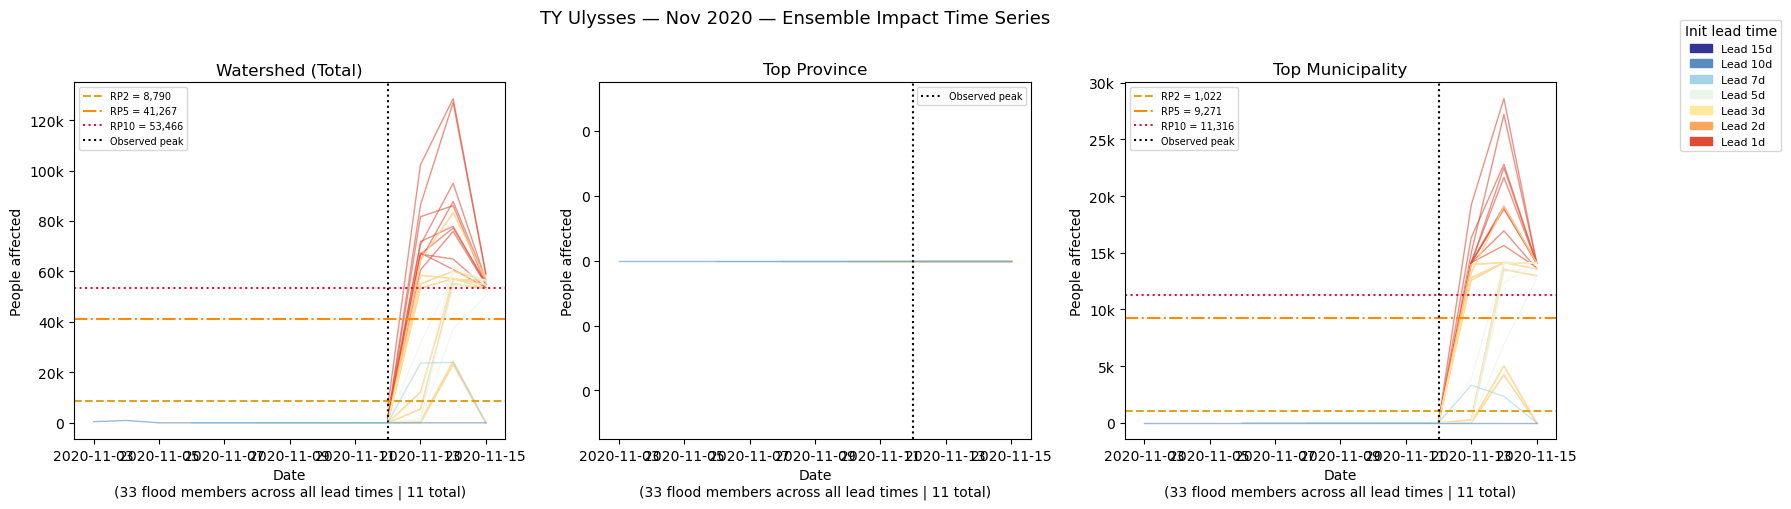

In [60]:
# =============================================================================
# NB07 — Section 7: Ensemble Timing Plot (Spaghetti)
# Shows per-member impact time series coloured by initialization lead time.
# Communicates peak timing uncertainty and OEP threshold crossings.
# =============================================================================

_DISPLAY_UNITS = {
    "watershed": "WATERSHED::TOTAL",
    "top_province": next((u for u in unit_names if u.startswith("ADM2::")), None),
    "top_municipality": next((u for u in unit_names if u.startswith("ADM3::")), None),
}
_PANEL_LABELS = {
    "watershed": "Watershed (Total)",
    "top_province": "Top Province",
    "top_municipality": "Top Municipality",
}

for ev_id, ev_results in results.items():
    if not ev_results:
        continue
    ev_cfg = EVENTS[ev_id]
    peak_dt = pd.Timestamp(ev_cfg["peak_date"])

    # Collect impact time series across all lead times
    all_series = []   # list of (lead_days, member_id, DataFrame)
    for lead_days, res in ev_results.items():
        for mbr, imp_df in res.get("impact_timeseries", {}).items():
            all_series.append((lead_days, mbr, imp_df))
    if not all_series:
        print(f"  {ev_id}: no impact time series (full pipeline not run)")
        continue

    # Colormap: lead time → colour (high lead = blue, low lead = red)
    cmap = cm.get_cmap("RdYlBu_r", len(LEAD_TIMES_DAYS) + 1)
    lead_to_color = {ld: cmap(i) for i, ld in enumerate(sorted(LEAD_TIMES_DAYS, reverse=True))}

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
    fig.suptitle(f"{ev_cfg['label']} — Ensemble Impact Time Series", fontsize=13, y=1.01)

    for ax, (panel_key, panel_label) in zip(axes, _PANEL_LABELS.items()):
        unit = _DISPLAY_UNITS.get(panel_key)
        if unit is None or unit not in unit_names:
            ax.text(0.5, 0.5, "Unit not found", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(panel_label)
            continue

        for lead_days, mbr, imp_df in all_series:
            if unit not in imp_df.columns:
                continue
            series = imp_df[unit].fillna(0.0)
            ax.plot(series.index, series.values,
                    color=lead_to_color.get(lead_days, "grey"),
                    alpha=0.6, lw=1.0)

        # OEP threshold lines
        line_styles = {2: ("--", "goldenrod", "RP2"), 5: ("-.", "darkorange", "RP5"), 10: (":", "crimson", "RP10")}
        for rp, (ls, color, lbl) in line_styles.items():
            thr = impact_thresholds.get(unit, {}).get(rp, np.nan)
            if np.isfinite(thr) and thr > 0:
                ax.axhline(thr, ls=ls, color=color, lw=1.5, label=f"{lbl} = {thr:,.0f}")

        # Observed peak date
        ax.axvline(peak_dt, ls=":", color="black", lw=1.5, label="Observed peak")
        ax.set_title(panel_label)
        ax.set_xlabel("Date")
        ax.set_ylabel("People affected")
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k" if x >= 1000 else str(int(x))))
        ax.legend(fontsize=7)

        # Count total flood members
        n_flood_total = sum(
            len(res.get("flood_members", []))
            for res in ev_results.values()
        )
        n_total = next(iter(ev_results.values()), {}).get("n_total_members", "?")
        ax.set_xlabel(f"Date\n({n_flood_total} flood members across all lead times | {n_total} total)")

    # Legend for lead-time colours
    import matplotlib.patches as mpatches
    legend_patches = [
        mpatches.Patch(color=lead_to_color[ld], label=f"Lead {ld}d")
        for ld in sorted(LEAD_TIMES_DAYS, reverse=True)
    ]
    fig.legend(handles=legend_patches, title="Init lead time",
               loc="upper right", bbox_to_anchor=(1.12, 1.0), fontsize=8)
    plt.tight_layout()
    plt.show()


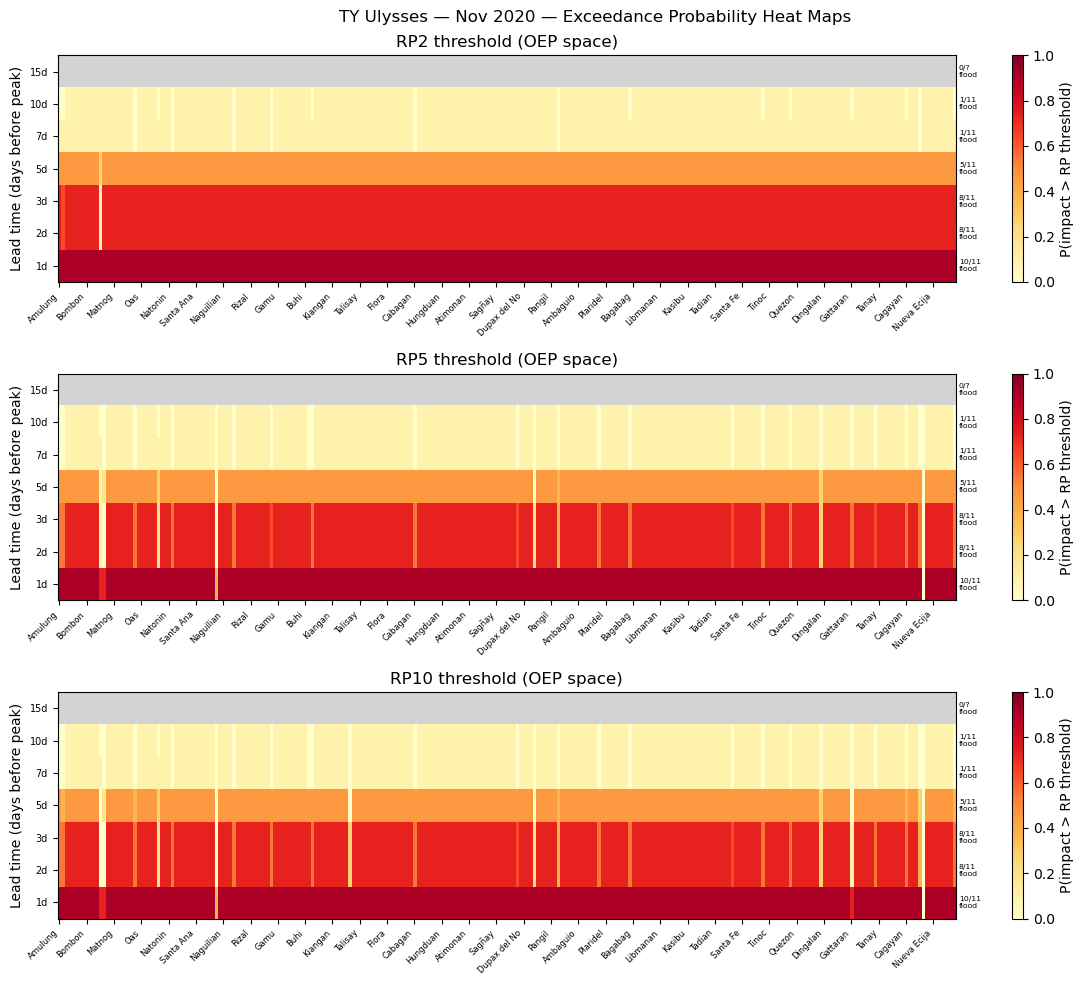

In [61]:
# =============================================================================
# NB07 — Section 8: Lead-Time Exceedance Probability Heatmaps
# Color = P(impact > OEP_RP_threshold | lead_time)  [0→1, YlOrRd]
# X-axis: lead time (inverted: 15d left → 1d right)
# Y-axis: spatial units (grouped by level)
# Grey = no GRIB data or zero flood members
# =============================================================================

for ev_id, ev_results in results.items():
    if not ev_results:
        continue
    ev_cfg = EVENTS[ev_id]
    peak_dt = pd.Timestamp(ev_cfg["peak_date"])

    # Build probability matrices: shape (n_units, n_leads, n_rps)
    n_units = len(unit_names)
    n_leads = len(LEAD_TIMES_DAYS)
    n_rps   = len(FLOOD_DETECT_RPS)

    prob_mat = np.full((n_units, n_leads, n_rps), np.nan)
    flood_count_mat = np.zeros((n_leads,), dtype=int)

    for li, lead_days in enumerate(LEAD_TIMES_DAYS):
        res = ev_results.get(lead_days)
        if res is None:
            continue
        flood_count_mat[li] = len(res["flood_members"])
        for ri, rp in enumerate(FLOOD_DETECT_RPS):
            p_arr = res["prob_exceed"].get(rp)
            if p_arr is not None:
                prob_mat[:, li, ri] = p_arr

    # Sort units: ADM3 then ADM2 then WATERSHED (already ordered)
    leads_inv = list(reversed(LEAD_TIMES_DAYS))   # 15d left

    fig, axes = plt.subplots(n_rps, 1, figsize=(12, 3 * n_rps + 1))
    if n_rps == 1:
        axes = [axes]
    fig.suptitle(f"{ev_cfg['label']} — Exceedance Probability Heat Maps", fontsize=12)

    cmap = plt.cm.YlOrRd
    cmap.set_bad("lightgrey")

    for ri, (rp, ax) in enumerate(zip(FLOOD_DETECT_RPS, axes)):
        # Re-order leads (inverted)
        data = np.full((n_units, len(leads_inv)), np.nan)
        for col_i, lead in enumerate(leads_inv):
            li = LEAD_TIMES_DAYS.index(lead)
            data[:, col_i] = prob_mat[:, li, ri]

        im = ax.imshow(data.T, aspect="auto", cmap=cmap, vmin=0, vmax=1, origin="upper")
        ax.set_title(f"RP{rp} threshold (OEP space)")
        ax.set_yticks(range(len(leads_inv)))
        ax.set_yticklabels([f"{l}d" for l in leads_inv], fontsize=7)
        ax.set_ylabel("Lead time (days before peak)")
        # X-axis: unit names (only show every nth to avoid crowding)
        step = max(1, n_units // 30)
        ax.set_xticks(range(0, n_units, step))
        ax.set_xticklabels(
            [unit_names[i].split("::")[1][:12] for i in range(0, n_units, step)],
            rotation=45, ha="right", fontsize=6,
        )

        # Annotate flood member counts
        for col_i, lead in enumerate(leads_inv):
            li = LEAD_TIMES_DAYS.index(lead)
            n_fl = flood_count_mat[li]
            n_tot = ev_results.get(lead, {}).get("n_total_members", "?")
            ax.text(n_units + 0.5, col_i, f"{n_fl}/{n_tot}\nflood",
                    va="center", ha="left", fontsize=5.5)

        plt.colorbar(im, ax=ax, label="P(impact > RP threshold)")

    plt.tight_layout()
    plt.show()


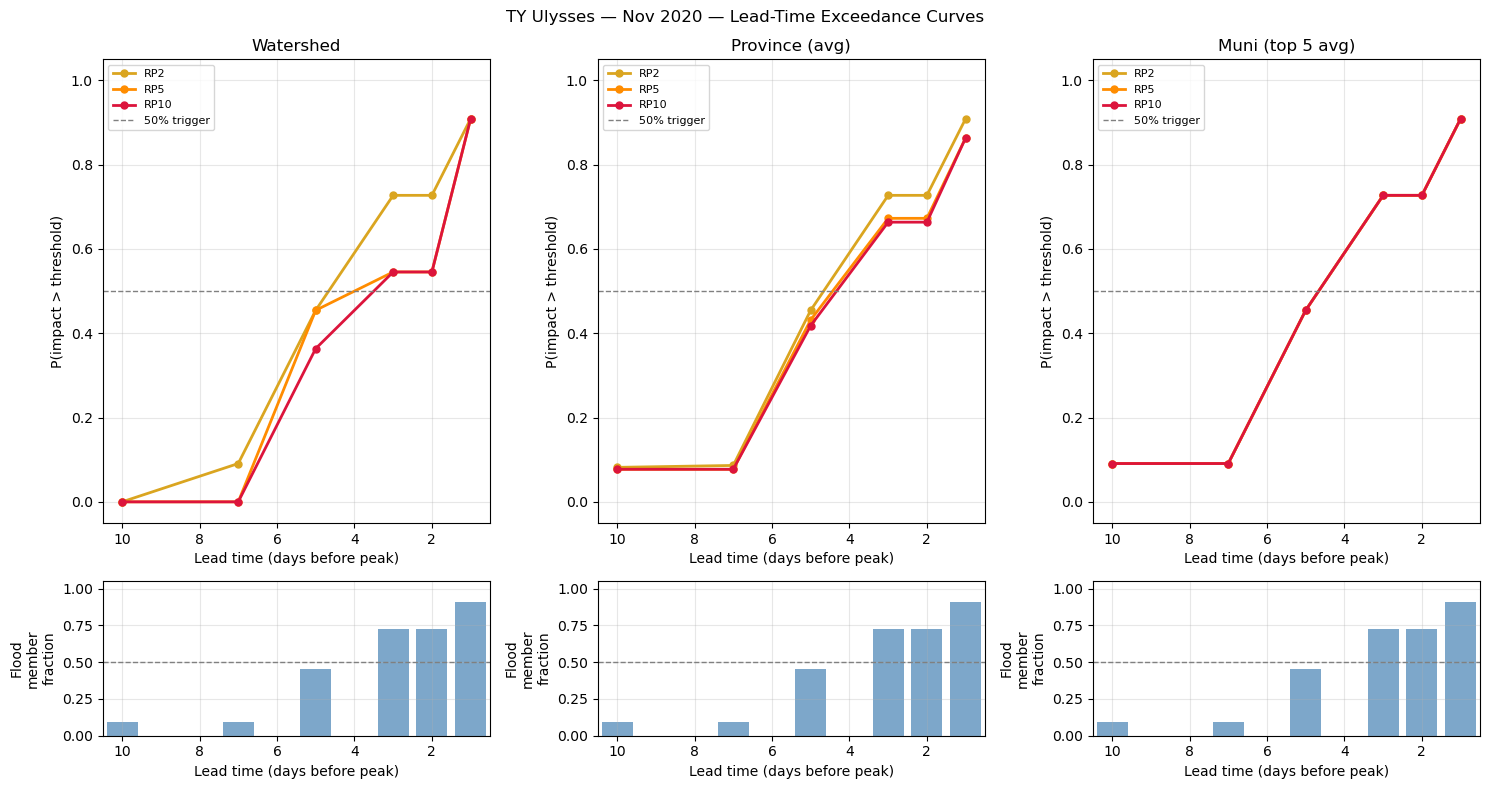

In [62]:
# =============================================================================
# NB07 — Section 9: Lead-Time Exceedance Probability Curves
# X: lead time (inverted, 15d→1d)  |  Y: P(impact > OEP threshold)
# One panel per spatial level  |  Three lines: RP2 / RP5 / RP10
# Lower panel: flood-member detection ratio (Phase 1 filter)
# =============================================================================

_RP_COLORS   = {2: "goldenrod", 5: "darkorange", 10: "crimson"}
_LEVEL_UNITS = {
    "Watershed": "WATERSHED::TOTAL",
    "Province (avg)": None,    # aggregated below
    "Municipality (max)": None,
}

for ev_id, ev_results in results.items():
    if not ev_results:
        continue
    ev_cfg = EVENTS[ev_id]
    leads_plot = sorted([l for l in LEAD_TIMES_DAYS if l in ev_results], reverse=True)
    if not leads_plot:
        continue

    fig, axes = plt.subplots(2, 3, figsize=(15, 8),
                              gridspec_kw={"height_ratios": [3, 1]})
    fig.suptitle(f"{ev_cfg['label']} — Lead-Time Exceedance Curves", fontsize=12)

    panel_units = [
        ("Watershed",       "WATERSHED::TOTAL"),
        ("Province (avg)",  None),
        ("Muni (top 5 avg)",None),
    ]

    for col, (panel_title, unit_key) in enumerate(panel_units):
        ax_main = axes[0, col]
        ax_bot  = axes[1, col]

        for rp, color in _RP_COLORS.items():
            probs = []
            for lead in leads_plot:
                res = ev_results.get(lead, {})
                p_arr = res.get("prob_exceed", {}).get(rp, np.zeros(len(unit_names)))
                if unit_key is not None and unit_key in unit_names:
                    ui = unit_names.index(unit_key)
                    probs.append(p_arr[ui])
                elif "Province" in panel_title:
                    prov_idx = [i for i, u in enumerate(unit_names) if u.startswith("ADM2::")]
                    probs.append(float(np.mean(p_arr[prov_idx])) if prov_idx else np.nan)
                else:
                    muni_idx = [i for i, u in enumerate(unit_names) if u.startswith("ADM3::")]
                    top5 = sorted(muni_idx, key=lambda i: p_arr[i], reverse=True)[:5]
                    probs.append(float(np.mean(p_arr[top5])) if top5 else np.nan)

            ax_main.plot(leads_plot, probs, color=color, marker="o", ms=5, lw=2,
                         label=f"RP{rp}")

        ax_main.axhline(TRIGGER_PROB_LINE, ls="--", color="grey", lw=1, label=f"{TRIGGER_PROB_LINE:.0%} trigger")
        ax_main.set_xlim(max(leads_plot) + 0.5, min(leads_plot) - 0.5)
        ax_main.set_ylim(-0.05, 1.05)
        ax_main.set_xlabel("Lead time (days before peak)")
        ax_main.set_ylabel("P(impact > threshold)")
        ax_main.set_title(panel_title)
        ax_main.legend(fontsize=8)
        ax_main.grid(True, alpha=0.3)

        # Bottom panel: flood member ratio
        ratios = []
        for lead in leads_plot:
            res = ev_results.get(lead, {})
            n_fl  = len(res.get("flood_members", []))
            n_tot = res.get("n_total_members", 1) or 1
            ratios.append(n_fl / n_tot)
        ax_bot.bar(leads_plot, ratios, color="steelblue", alpha=0.7)
        ax_bot.axhline(0.5, ls="--", color="grey", lw=1)
        ax_bot.set_xlim(max(leads_plot) + 0.5, min(leads_plot) - 0.5)
        ax_bot.set_ylim(0, 1.05)
        ax_bot.set_xlabel("Lead time (days before peak)")
        ax_bot.set_ylabel("Flood\nmember\nfraction")
        ax_bot.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


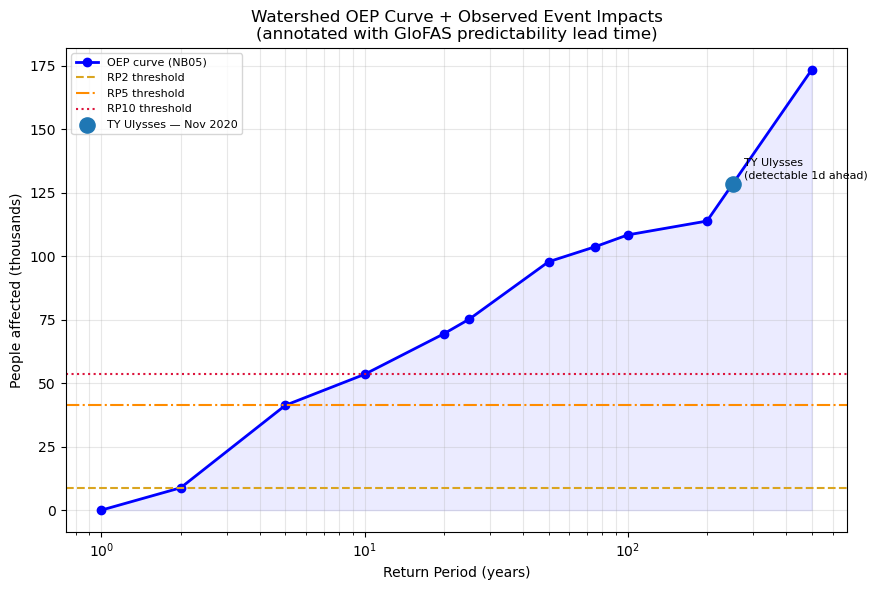

In [63]:
# =============================================================================
# NB07 — Section 10: OEP Context Scatter
# Plot NB05 watershed OEP curve with observed event impacts overlaid.
# Annotate each event with the maximum lead time at which P(RP10) > 50%.
# =============================================================================

_ws_oep = np.array(oep_all["units"][-1]["oep_rl"])  # WATERSHED::TOTAL is last
_rp_arr = np.array(RP_REPORT)

fig, ax = plt.subplots(figsize=(9, 6))

# OEP curve
ax.plot(_rp_arr, _ws_oep / 1e3, "b-o", lw=2, ms=6, label="OEP curve (NB05)")
ax.fill_between(_rp_arr, _ws_oep / 1e3, alpha=0.08, color="blue")

# Threshold lines
for rp, (ls, color) in {2: ("--", "goldenrod"), 5: ("-.", "darkorange"), 10: (":", "crimson")}.items():
    thr_idx = list(_rp_arr).index(rp) if rp in _rp_arr else None
    if thr_idx is not None:
        ax.axhline(_ws_oep[thr_idx] / 1e3, ls=ls, color=color, lw=1.5, label=f"RP{rp} threshold")

# Observed events
for ev_id, ev_results in results.items():
    ev_cfg = EVENTS[ev_id]
    peak_dt = pd.Timestamp(ev_cfg["peak_date"])
    if not ev_results:
        continue

    # Find max observed impact from the phase-2 timeseries at any lead time
    max_impact = 0.0
    max_lead_above_50pct_rp10 = None
    for lead_days in sorted(ev_results.keys(), reverse=True):
        res = ev_results[lead_days]
        # Check P(RP10) > 50% for watershed
        ws_idx = unit_names.index("WATERSHED::TOTAL") if "WATERSHED::TOTAL" in unit_names else -1
        if ws_idx >= 0:
            p_rp10 = res.get("prob_exceed", {}).get(10, np.zeros(len(unit_names)))[ws_idx]
            if p_rp10 >= TRIGGER_PROB_LINE:
                max_lead_above_50pct_rp10 = lead_days
        for mbr, imp_df in res.get("impact_timeseries", {}).items():
            if "WATERSHED::TOTAL" in imp_df.columns:
                max_impact = max(max_impact, imp_df["WATERSHED::TOTAL"].max())

    # Determine observed RP from OEP inversion
    obs_rp = invert_oep_curve_to_rp(max_impact, _rp_arr, _ws_oep)
    obs_rp_plot = min(obs_rp, float(_rp_arr.max()))

    ax.scatter(obs_rp_plot, max_impact / 1e3, s=120, zorder=5, label=ev_cfg["label"])
    label_txt = ev_cfg["label"].split("\u2014")[0].strip()
    if max_lead_above_50pct_rp10:
        label_txt += f"\n(detectable {max_lead_above_50pct_rp10}d ahead)"
    ax.annotate(label_txt, (obs_rp_plot, max_impact / 1e3),
                textcoords="offset points", xytext=(8, 4), fontsize=8)

ax.set_xscale("log")
ax.set_xlabel("Return Period (years)")
ax.set_ylabel("People affected (thousands)")
ax.set_title("Watershed OEP Curve + Observed Event Impacts\n(annotated with GloFAS predictability lead time)")
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()
